# Quantitative comparison across generation conditions

Evaluates both **obj-crop** and **full-image** reconstructions from `outputs/generate_hvm_obj_backup_20260503/` across all 90 test stimuli.

**Crop conditions** (5 columns in crop strips):
0. `Original` — GT bbox crop (reference)
1. `Control (null)` — img2img with zero SigLIP / no text
2. `Text (cat CLIP+T5)` — category text only
3. `Neural pred (obj)` — obj-SigLIP predicted from neural responses
4. `GT emb (obj ↑)` — oracle: ground-truth obj-SigLIP injected

**Full conditions** (6 columns in full strips):
0. `Original` — full HVM stimulus (reference)
1. `Control (null img2img)` — img2img, zero SigLIP / no text
2. `Control (null seq)` — sequential, zero SigLIP / no text
3. `Text (cat CLIP+T5)` — sequential, category text only
4. `Neural pred (seq)` — sequential, obj+global SigLIP from neural pred
5. `GT emb (seq ↑)` — oracle: ground-truth SigLIP injected sequentially

**Metrics** (all computed against the GT reference image):
- SSIM (structural similarity, ↑)
- PixCorr (Pearson r on flattened pixels, ↑)
- LPIPS/VGG (perceptual distance, ↓)
- SigLIP-cos (cosine sim between re-embedded recon and GT SigLIP, ↑)
- 2-AFC identification (pairwise across 90 test images, ↑; chance = 0.5)

In [ ]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import lpips

sys.path.insert(0, '.')
from config_const import (
    SEED, HVM_OBJ_SIGLIP_EMBEDDINGS_PATH, HVM_SIGLIP_EMBEDDINGS_PATH,
    HVM_CATEGORIES, HVM_N_VAR,
)
from data_utils.hvm_loader import _category_stratified_split
from encoders.siglip_embed import load_siglip, embed_images_stripped
from eval.metrics import two_afc_identification
from get_device import get_device

DEVICE   = get_device()
OUTPUT_DIR = Path('outputs/generate_hvm_obj')
CROP_DIR = OUTPUT_DIR / 'crop'
FULL_DIR = OUTPUT_DIR / 'full'
IMG_SIZE = 512
LABEL_H  = 36

# Crop: 5 cols — col 0 = original, cols 1-4 = conditions
CROP_COND_NAMES = ['Control\n(null)', 'Text\n(cat CLIP+T5)', 'Neural pred\n(obj)', 'GT emb\n(obj ↑)']
CROP_COND_KEYS  = ['control', 'text', 'neural', 'gt']

# Full: 6 cols — col 0 = original, cols 1-5 = conditions
# col 1 (ctrl_i2i) is excluded; we load all 5 but only analyse cols 2-5
FULL_ALL_KEYS   = ['ctrl_i2i', 'ctrl_seq', 'text', 'neural', 'gt']
FULL_COND_NAMES = ['Control\n(null seq)', 'Text\n(cat CLIP+T5)', 'Neural pred\n(seq)', 'GT emb\n(seq ↑)']
FULL_COND_KEYS  = ['ctrl_seq', 'text', 'neural', 'gt']

_, _, test_idx = _category_stratified_split(SEED)
test_idx = [int(i) for i in test_idx]
N = len(test_idx)
print(f'{N} test stimuli')

90 test stimuli


In [32]:
# Load crop strip PNGs (5 cols) and full strip PNGs (6 cols)
# Full col 1 (ctrl_i2i) is loaded but dropped — only FULL_COND_KEYS are kept

crop_originals = []
crop_recons    = {k: [] for k in CROP_COND_KEYS}

for stim_idx in test_idx:
    strip = Image.open(CROP_DIR / f'stim{stim_idx:04d}.png').convert('RGB')
    for col, key in enumerate(['orig'] + CROP_COND_KEYS):
        patch = strip.crop((col * IMG_SIZE, LABEL_H, (col + 1) * IMG_SIZE, LABEL_H + IMG_SIZE))
        if key == 'orig':
            crop_originals.append(patch)
        else:
            crop_recons[key].append(patch)

full_originals = []
full_recons    = {k: [] for k in FULL_COND_KEYS}

for stim_idx in test_idx:
    strip = Image.open(FULL_DIR / f'stim{stim_idx:04d}.png').convert('RGB')
    for col, key in enumerate(['orig'] + FULL_ALL_KEYS):
        patch = strip.crop((col * IMG_SIZE, LABEL_H, (col + 1) * IMG_SIZE, LABEL_H + IMG_SIZE))
        if key == 'orig':
            full_originals.append(patch)
        elif key in full_recons:
            full_recons[key].append(patch)

print(f'Crop: {len(crop_originals)} originals, {len(crop_recons["neural"])} recons per condition')
print(f'Full: {len(full_originals)} originals, {len(full_recons["neural"])} recons per condition')

Crop: 90 originals, 90 recons per condition
Full: 90 originals, 90 recons per condition


In [33]:
# Pixel-level tensors and GT SigLIP embeddings for both crop and full
to_tensor = T.ToTensor()

crop_orig_t = torch.stack([to_tensor(o) for o in crop_originals])  # (N, 3, H, W)
full_orig_t = torch.stack([to_tensor(o) for o in full_originals])   # (N, 3, H, W)

# Crop: compare against GT bbox-crop SigLIP embeddings
siglip_obj_gt  = torch.load(HVM_OBJ_SIGLIP_EMBEDDINGS_PATH, weights_only=True)  # (450, 1152)
crop_sig_gt    = siglip_obj_gt[test_idx]                                          # (N, 1152)
crop_sig_gt_n  = F.normalize(crop_sig_gt, dim=-1)

# Full: compare against GT full-image SigLIP embeddings
siglip_full_gt = torch.load(HVM_SIGLIP_EMBEDDINGS_PATH, weights_only=True)       # (450, 1152)
full_sig_gt    = siglip_full_gt[test_idx]                                         # (N, 1152)
full_sig_gt_n  = F.normalize(full_sig_gt, dim=-1)

print(f'crop_sig_gt: {tuple(crop_sig_gt.shape)}, full_sig_gt: {tuple(full_sig_gt.shape)}')

crop_sig_gt: (90, 1152), full_sig_gt: (90, 1152)


In [34]:
# Embed all crop + full recons in one SigLIP pass, then unload the model
# Order: crop conditions (4×N) then full conditions (4×N) = 720 images total
siglip_proc, siglip_model = load_siglip(device=DEVICE)

all_imgs = (
    [img for key in CROP_COND_KEYS for img in crop_recons[key]] +
    [img for key in FULL_COND_KEYS for img in full_recons[key]]
)
all_sigs = embed_images_stripped(siglip_proc, siglip_model, all_imgs)  # (720, 1152)

n_crop = len(CROP_COND_KEYS) * N
crop_sigs = {key: all_sigs[i*N:(i+1)*N] for i, key in enumerate(CROP_COND_KEYS)}
full_sigs = {key: all_sigs[n_crop + i*N : n_crop + (i+1)*N] for i, key in enumerate(FULL_COND_KEYS)}

del siglip_proc, siglip_model, all_imgs, all_sigs
torch.cuda.empty_cache()

lpips_fn = lpips.LPIPS(net='vgg').cpu()
print('Embeddings computed, SigLIP unloaded, LPIPS ready')

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
Embeddings computed, SigLIP unloaded, LPIPS ready


In [35]:
from skimage.metrics import structural_similarity

def compute_metrics(imgs, rec_sigs, orig_t, sig_gt, sig_gt_norm, batch_size=8):
    """Per-stimulus metric arrays. sig_gt / sig_gt_norm are the GT SigLIP tensors for this image set."""
    n = len(imgs)
    rec_t = torch.stack([to_tensor(r) for r in imgs])  # (N, 3, H, W)

    ssim_vals = np.array([
        structural_similarity(
            rec_t[i].numpy().transpose(1, 2, 0),
            orig_t[i].numpy().transpose(1, 2, 0),
            channel_axis=-1, data_range=1.0)
        for i in range(n)
    ])

    lp_vals = []
    with torch.no_grad():
        for i in range(0, n, batch_size):
            r_b = rec_t[i:i+batch_size] * 2 - 1
            o_b = orig_t[i:i+batch_size] * 2 - 1
            lp_vals.extend(lpips_fn(r_b, o_b).squeeze().tolist())
    lp_vals = np.array(lp_vals)

    rec_flat  = rec_t.numpy().reshape(n, -1)
    orig_flat = orig_t.numpy().reshape(n, -1)
    pixcorr_vals = np.array([np.corrcoef(rec_flat[i], orig_flat[i])[0, 1] for i in range(n)])

    cos_vals = F.cosine_similarity(rec_sigs, sig_gt_norm, dim=-1).numpy()

    return dict(
        ssim=ssim_vals,
        lpips=lp_vals,
        pixcorr=pixcorr_vals,
        siglip_cos=cos_vals,
        afc_2=two_afc_identification(rec_sigs, sig_gt),
    )


crop_results = {}
print('=== Crop ===')
for key, name in zip(CROP_COND_KEYS, CROP_COND_NAMES):
    label = name.replace('\n', ' ')
    print(f'  {label}...')
    crop_results[key] = compute_metrics(
        crop_recons[key], crop_sigs[key], crop_orig_t, crop_sig_gt, crop_sig_gt_n)
    m = crop_results[key]
    print(f'    SSIM={m["ssim"].mean():.4f}  LPIPS={m["lpips"].mean():.4f}  '
          f'PixCorr={m["pixcorr"].mean():.4f}  SigLIP-cos={m["siglip_cos"].mean():.4f}  '
          f'2-AFC={m["afc_2"]:.4f}')

full_results = {}
print('\n=== Full ===')
for key, name in zip(FULL_COND_KEYS, FULL_COND_NAMES):
    label = name.replace('\n', ' ')
    print(f'  {label}...')
    full_results[key] = compute_metrics(
        full_recons[key], full_sigs[key], full_orig_t, full_sig_gt, full_sig_gt_n)
    m = full_results[key]
    print(f'    SSIM={m["ssim"].mean():.4f}  LPIPS={m["lpips"].mean():.4f}  '
          f'PixCorr={m["pixcorr"].mean():.4f}  SigLIP-cos={m["siglip_cos"].mean():.4f}  '
          f'2-AFC={m["afc_2"]:.4f}')

print('\nDone.')

=== Crop ===
  Control (null)...
    SSIM=0.7760  LPIPS=0.4283  PixCorr=0.9228  SigLIP-cos=0.7664  2-AFC=0.9197
  Text (cat CLIP+T5)...
    SSIM=0.7764  LPIPS=0.4242  PixCorr=0.9229  SigLIP-cos=0.8261  2-AFC=0.9667
  Neural pred (obj)...
    SSIM=0.8046  LPIPS=0.4146  PixCorr=0.9322  SigLIP-cos=0.8077  2-AFC=0.9130
  GT emb (obj ↑)...
    SSIM=0.8019  LPIPS=0.4115  PixCorr=0.9318  SigLIP-cos=0.8297  2-AFC=0.9624

=== Full ===
  Control (null seq)...
    SSIM=0.7589  LPIPS=0.3238  PixCorr=0.9279  SigLIP-cos=0.7919  2-AFC=0.8943
  Text (cat CLIP+T5)...
    SSIM=0.7599  LPIPS=0.3223  PixCorr=0.9284  SigLIP-cos=0.8226  2-AFC=0.9593
  Neural pred (seq)...
    SSIM=0.7835  LPIPS=0.3196  PixCorr=0.9377  SigLIP-cos=0.8275  2-AFC=0.9175
  GT emb (seq ↑)...
    SSIM=0.7809  LPIPS=0.3131  PixCorr=0.9370  SigLIP-cos=0.8504  2-AFC=0.9723

Done.


In [36]:
import pandas as pd

METRIC_KEYS   = ['ssim', 'lpips', 'pixcorr', 'siglip_cos', 'afc_2']
METRIC_LABELS = ['SSIM ↑', 'LPIPS ↓', 'PixCorr ↑', 'SigLIP-cos ↑', '2-AFC ↑']

def make_table(results, cond_keys, cond_names, caption):
    rows = {}
    for key, name in zip(cond_keys, cond_names):
        row = {}
        for mk, ml in zip(METRIC_KEYS, METRIC_LABELS):
            v = results[key][mk]
            if isinstance(v, np.ndarray):
                row[ml] = f'{v.mean():.4f} ± {v.std()/np.sqrt(len(v)):.4f}'
            else:
                row[ml] = f'{v:.4f}'
        rows[name.replace(chr(10), ' ')] = row
    df = pd.DataFrame(rows, index=METRIC_LABELS).T
    df.index.name = 'Condition'

    def highlight_best(s):
        means = np.array([float(v.split(' ')[0]) for v in s])
        higher_better = '↓' not in s.name
        best = int(np.argmin(means) if not higher_better else np.argmax(means))
        return ['font-weight: bold; background-color: #d4edda' if i == best else '' for i in range(len(means))]

    return df.style.apply(highlight_best).set_caption(caption)

display(make_table(crop_results, CROP_COND_KEYS, CROP_COND_NAMES,
                   'Crop — mean ± SEM, 90 test stimuli'))
display(make_table(full_results, FULL_COND_KEYS, FULL_COND_NAMES,
                   'Full — mean ± SEM, 90 test stimuli'))

,SSIM ↑,LPIPS ↓,PixCorr ↑,SigLIP-cos ↑,2-AFC ↑
Condition,,,,,
Control (null),0.7760 ± 0.0103,0.4283 ± 0.0073,0.9228 ± 0.0052,0.7664 ± 0.0103,0.9197
Text (cat CLIP+T5),0.7764 ± 0.0104,0.4242 ± 0.0074,0.9229 ± 0.0051,0.8261 ± 0.0091,0.9667
Neural pred (obj),0.8046 ± 0.0095,0.4146 ± 0.0078,0.9322 ± 0.0046,0.8077 ± 0.0091,0.9130
GT emb (obj ↑),0.8019 ± 0.0097,0.4115 ± 0.0075,0.9318 ± 0.0047,0.8297 ± 0.0077,0.9624


,SSIM ↑,LPIPS ↓,PixCorr ↑,SigLIP-cos ↑,2-AFC ↑
Condition,,,,,
Control (null seq),0.7589 ± 0.0087,0.3238 ± 0.0046,0.9279 ± 0.0048,0.7919 ± 0.0093,0.8943
Text (cat CLIP+T5),0.7599 ± 0.0087,0.3223 ± 0.0046,0.9284 ± 0.0048,0.8226 ± 0.0084,0.9593
Neural pred (seq),0.7835 ± 0.0087,0.3196 ± 0.0045,0.9377 ± 0.0042,0.8275 ± 0.0076,0.9175
GT emb (seq ↑),0.7809 ± 0.0087,0.3131 ± 0.0044,0.9370 ± 0.0044,0.8504 ± 0.0064,0.9723


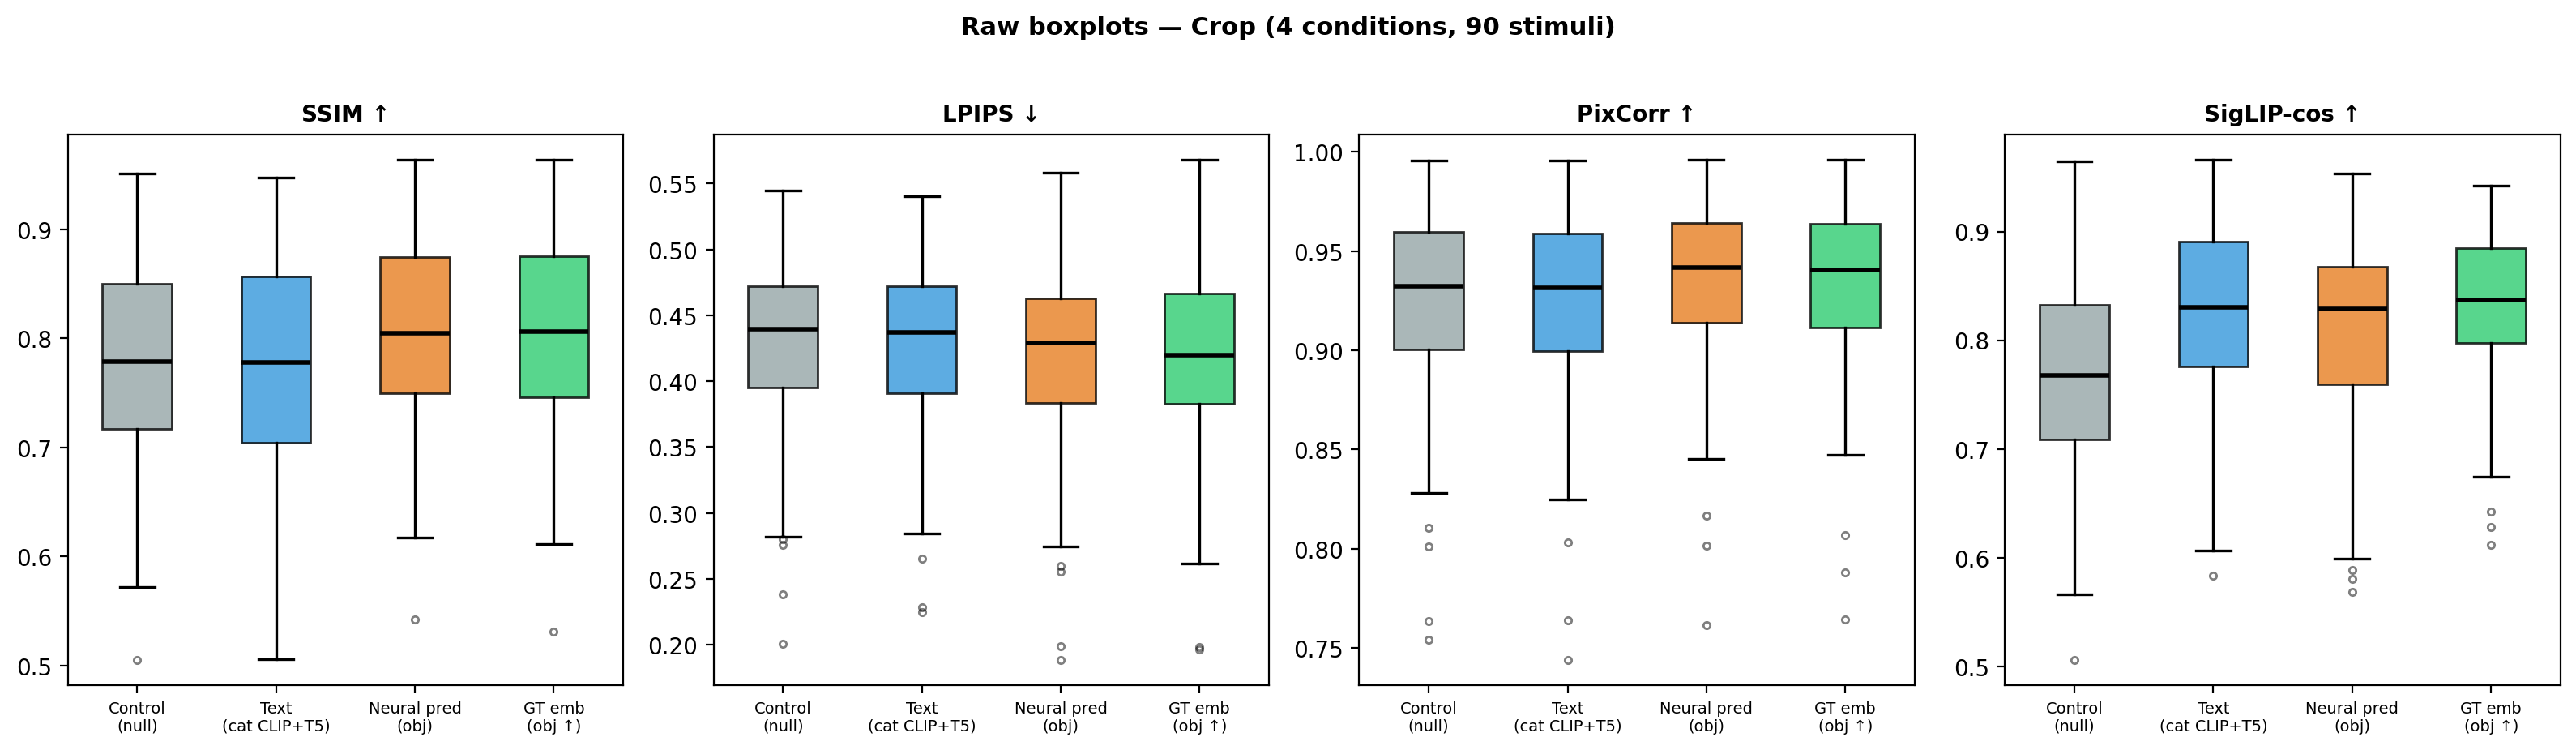

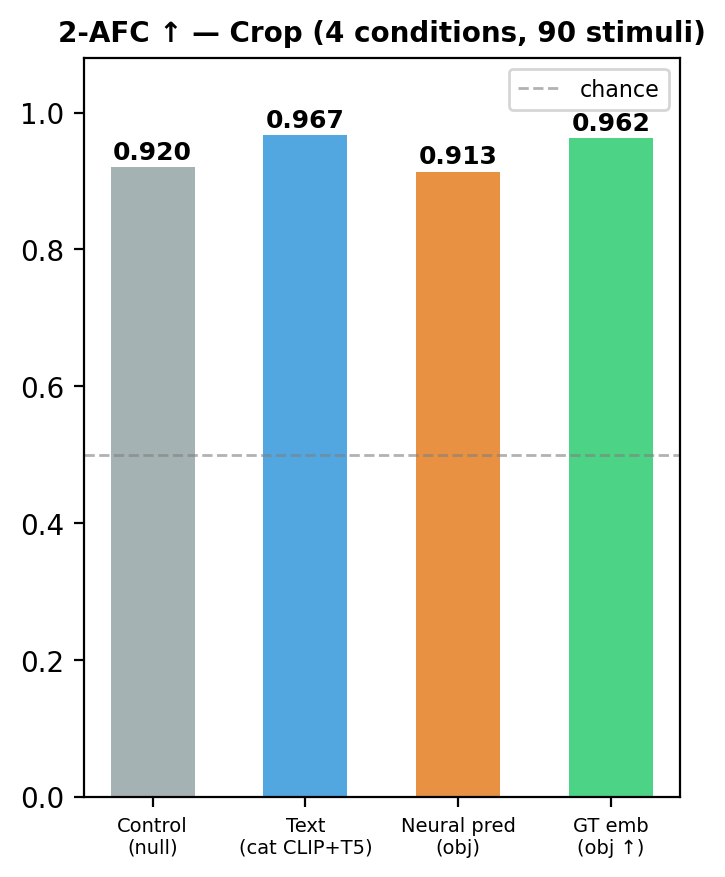

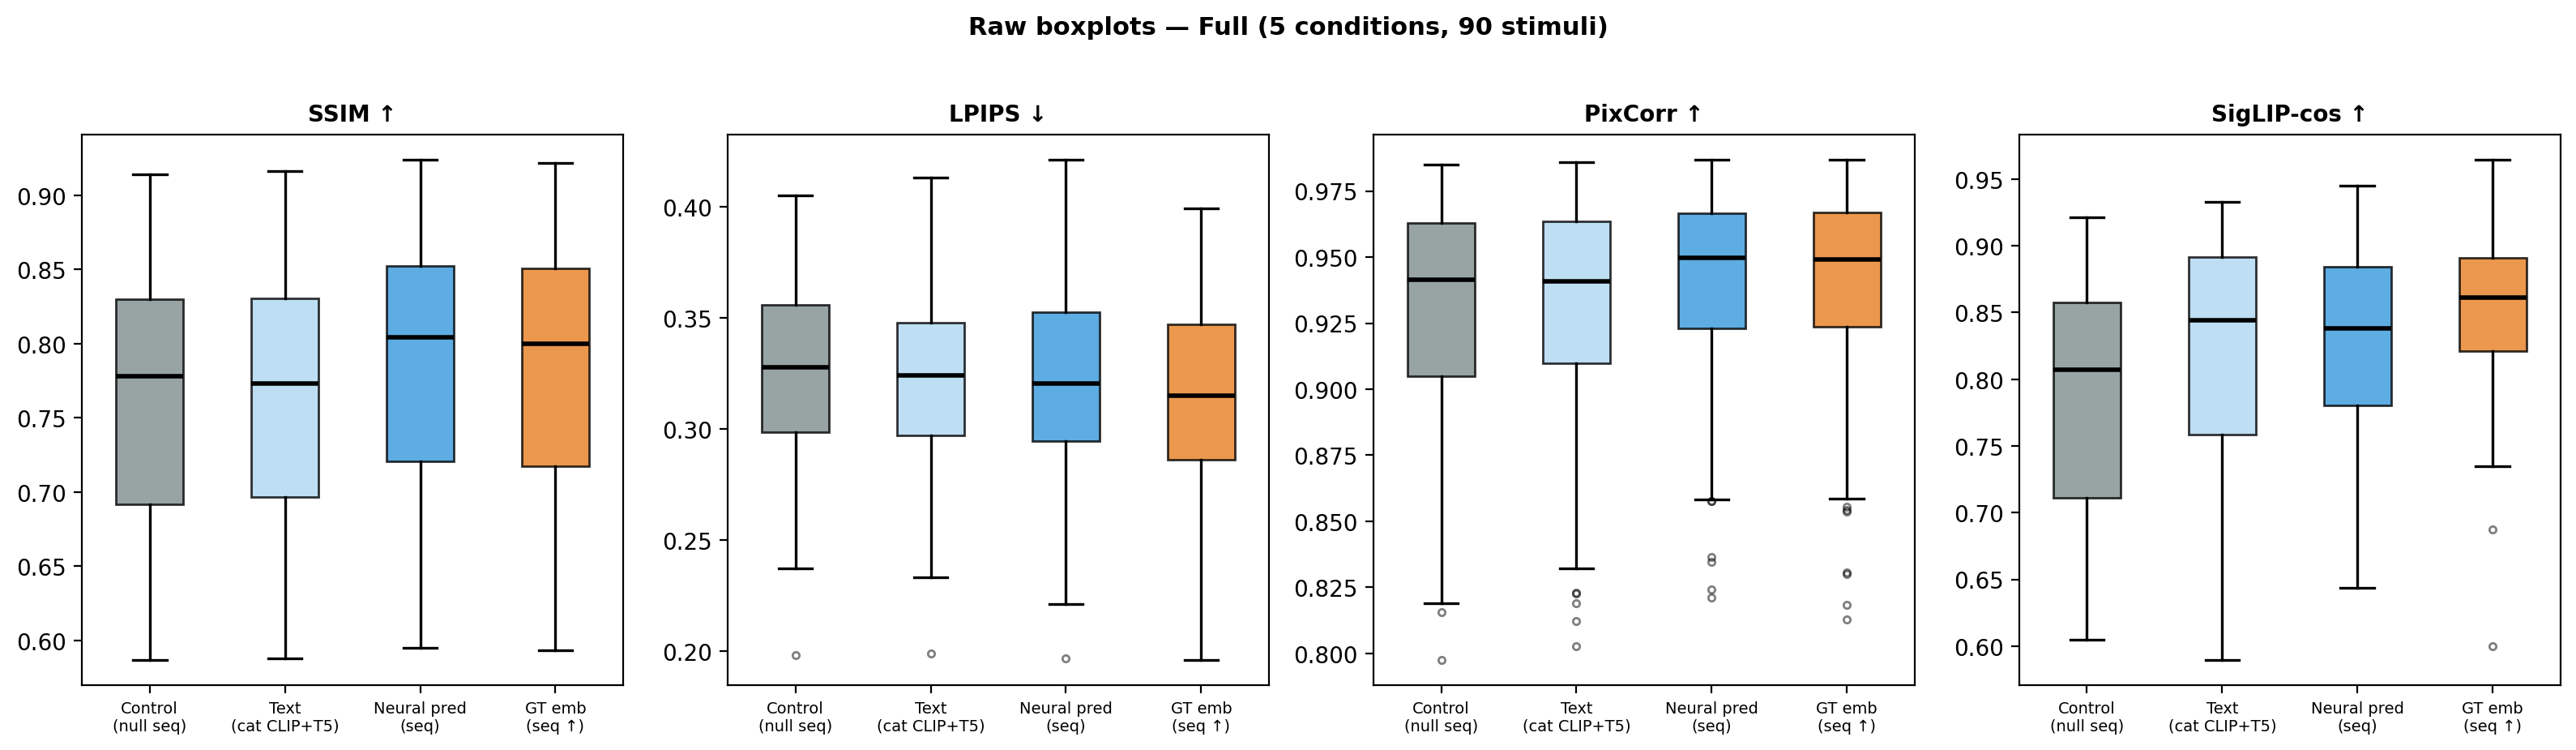

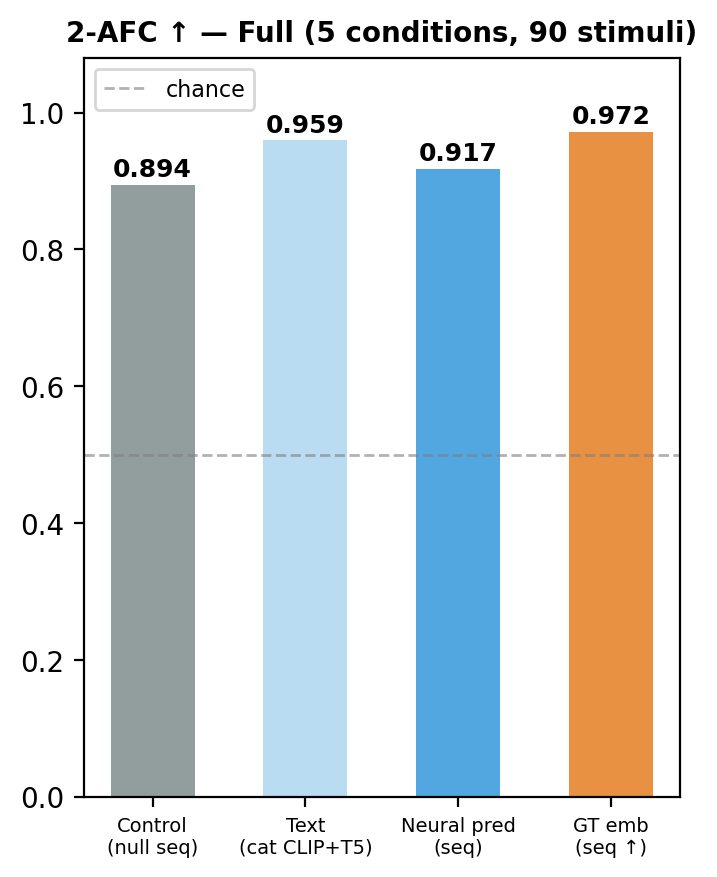

In [37]:
import matplotlib.pyplot as plt

BOXPLOT_METRICS = [
    ('ssim',       'SSIM ↑'),
    ('lpips',      'LPIPS ↓'),
    ('pixcorr',    'PixCorr ↑'),
    ('siglip_cos', 'SigLIP-cos ↑'),
]
CROP_COLORS = ['#95a5a6', '#3498db', '#e67e22', '#2ecc71']
FULL_COLORS = ['#7f8c8d', '#aed6f1', '#3498db', '#e67e22', '#2ecc71']

def make_boxplot_row(results, cond_keys, cond_names, colors, title_suffix):
    labels = [n.replace('\n', '\n') for n in cond_names]
    fig, axes = plt.subplots(1, len(BOXPLOT_METRICS), figsize=(16, 4.5))
    for ax, (key, title) in zip(axes, BOXPLOT_METRICS):
        data = [results[k][key] for k in cond_keys]
        bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                        medianprops=dict(color='black', lw=2),
                        whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                        flierprops=dict(marker='o', markersize=3, alpha=0.5))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
        ax.set_xticks(range(1, len(cond_keys) + 1))
        ax.set_xticklabels(labels, fontsize=7)
        ax.set_title(title, fontsize=10, fontweight='bold')
    fig.suptitle(f'Raw boxplots — {title_suffix}', fontsize=11, fontweight='bold', y=1.02)
    fig.tight_layout()
    fig.show()

    # 2-AFC bar
    fig2, ax2 = plt.subplots(figsize=(max(3.5, len(cond_keys)*0.9), 4.5))
    afc_vals = [results[k]['afc_2'] for k in cond_keys]
    bars = ax2.bar(range(len(cond_keys)), afc_vals, color=colors, alpha=0.85, width=0.55)
    ax2.axhline(0.5, color='grey', lw=1, ls='--', alpha=0.6, label='chance')
    for bar, v in zip(bars, afc_vals):
        ax2.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.set_xticks(range(len(cond_keys)))
    ax2.set_xticklabels(labels, fontsize=7)
    ax2.set_title(f'2-AFC ↑ — {title_suffix}', fontsize=10, fontweight='bold')
    ax2.set_ylim(0, 1.08)
    ax2.legend(fontsize=8)
    fig2.tight_layout()
    fig2.show()

make_boxplot_row(crop_results, CROP_COND_KEYS, CROP_COND_NAMES, CROP_COLORS, 'Crop (4 conditions, 90 stimuli)')
make_boxplot_row(full_results, FULL_COND_KEYS, FULL_COND_NAMES, FULL_COLORS, 'Full (5 conditions, 90 stimuli)')

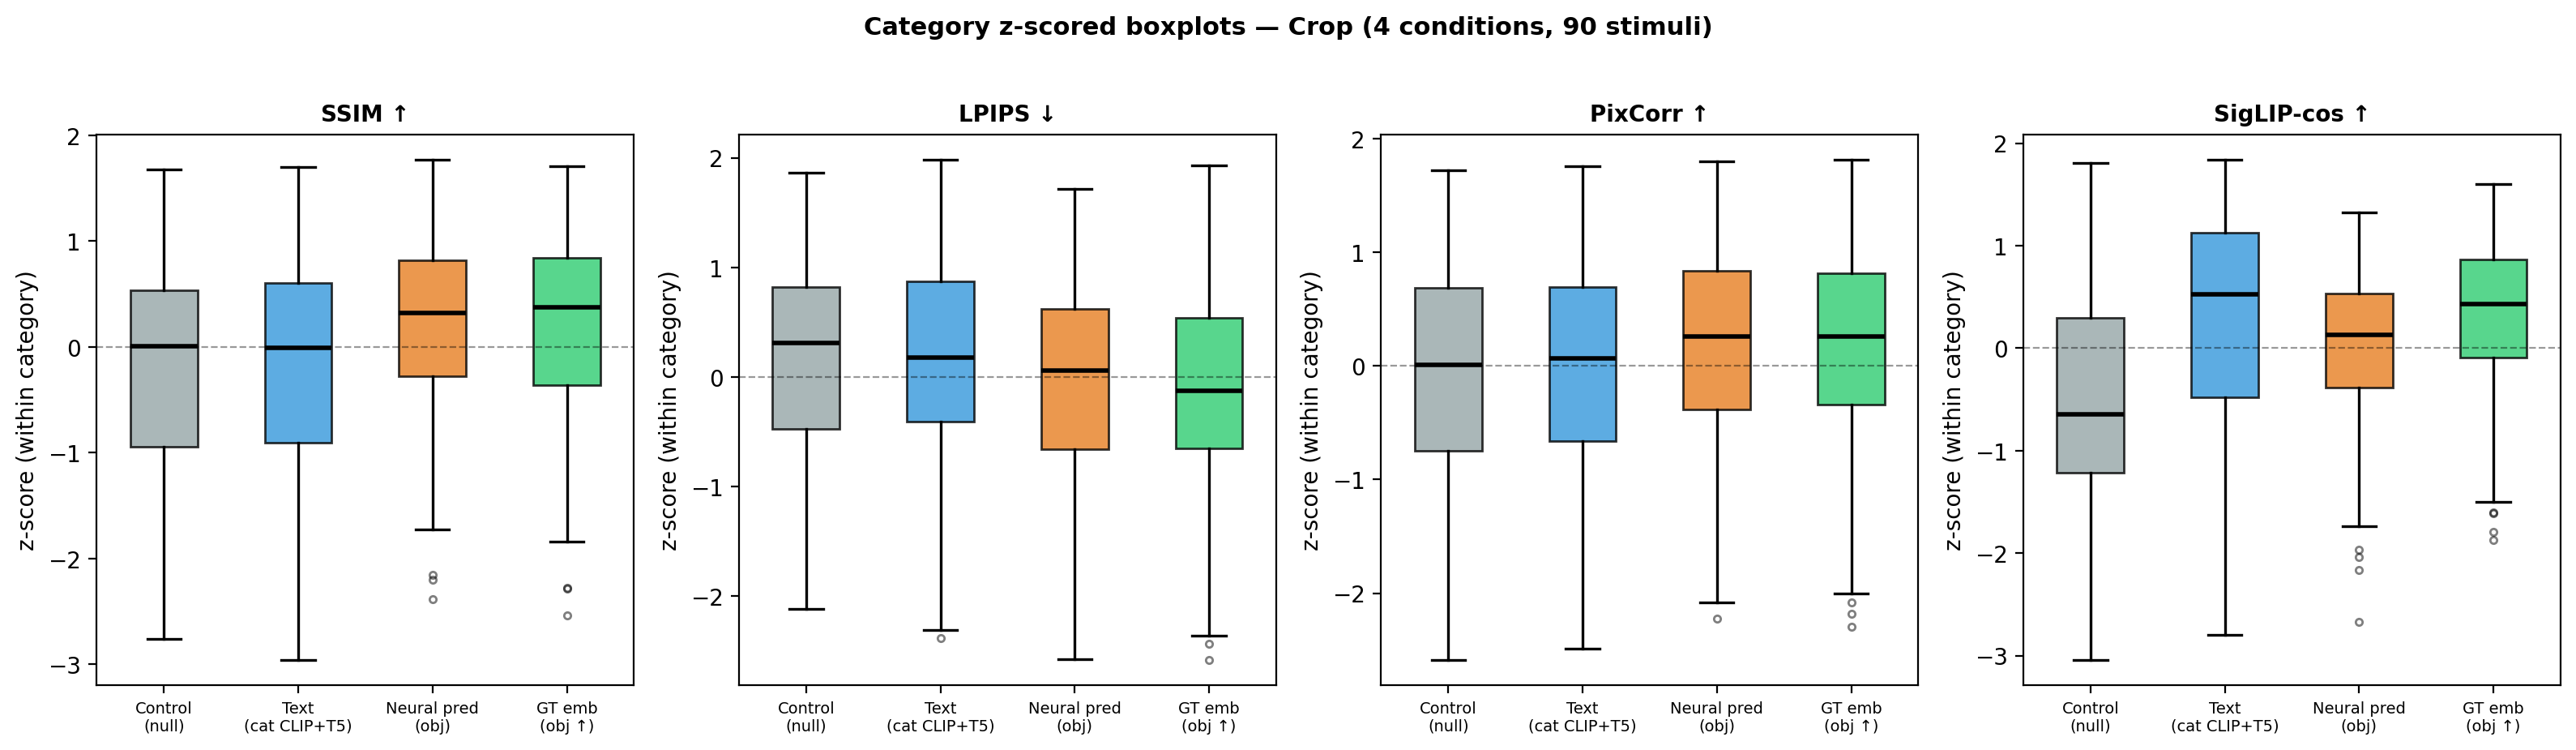

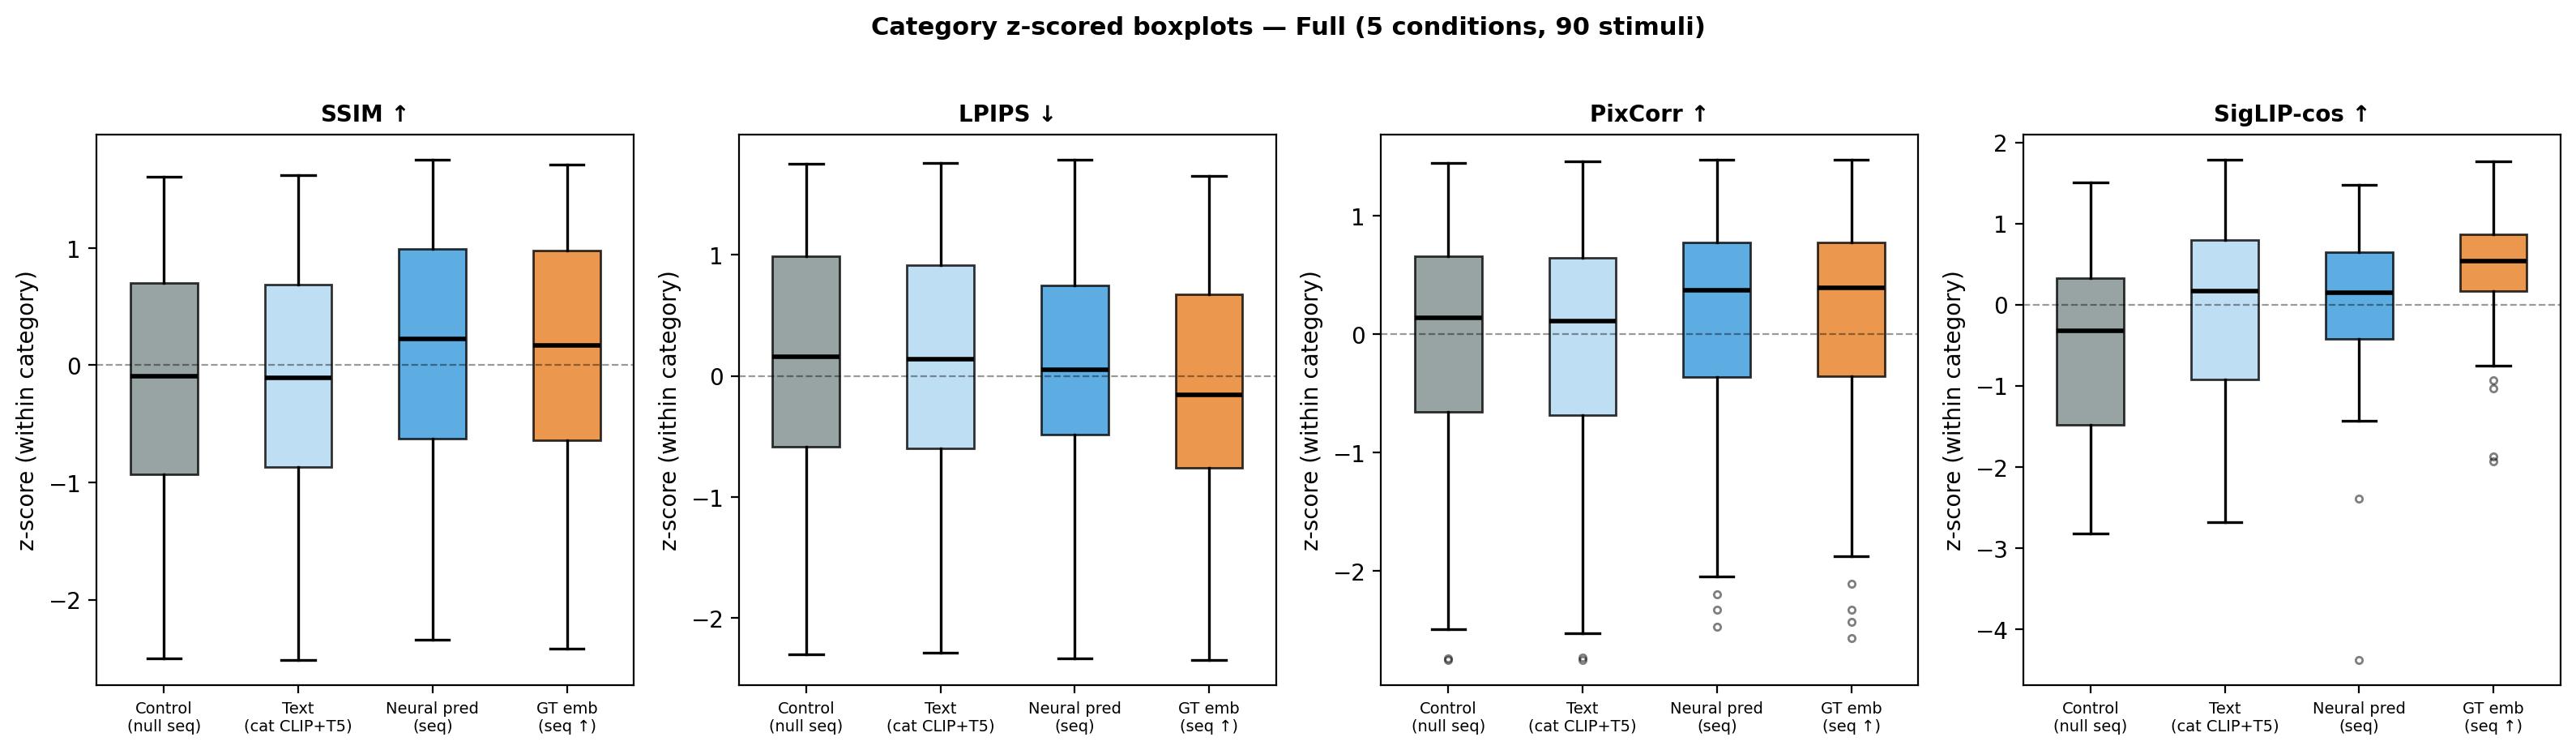

In [38]:
# Category z-scored boxplots — crop and full
cat_ids_arr = np.array(test_idx) // HVM_N_VAR   # (90,)

def category_zscore(results, cond_keys, metric_key):
    raw = np.stack([results[k][metric_key] for k in cond_keys], axis=1)  # (N, C)
    out = np.zeros_like(raw)
    for c in range(len(HVM_CATEGORIES)):
        mask = cat_ids_arr == c
        block = raw[mask]
        mu, std = block.mean(), block.std()
        out[mask] = (block - mu) / (std + 1e-8)
    return out

def make_zscore_boxplots(results, cond_keys, cond_names, colors, title_suffix):
    labels = [n.replace('\n', '\n') for n in cond_names]
    fig, axes = plt.subplots(1, len(BOXPLOT_METRICS), figsize=(16, 4.5))
    for ax, (key, title) in zip(axes, BOXPLOT_METRICS):
        zs   = category_zscore(results, cond_keys, key)
        data = [zs[:, i] for i in range(len(cond_keys))]
        bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                        medianprops=dict(color='black', lw=2),
                        whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                        flierprops=dict(marker='o', markersize=3, alpha=0.5))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)
        ax.set_xticks(range(1, len(cond_keys) + 1))
        ax.set_xticklabels(labels, fontsize=7)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_ylabel('z-score (within category)')
    fig.suptitle(f'Category z-scored boxplots — {title_suffix}', fontsize=11, fontweight='bold', y=1.02)
    fig.tight_layout()
    fig.show()

make_zscore_boxplots(crop_results, CROP_COND_KEYS, CROP_COND_NAMES, CROP_COLORS,
                     'Crop (4 conditions, 90 stimuli)')
make_zscore_boxplots(full_results, FULL_COND_KEYS, FULL_COND_NAMES, FULL_COLORS,
                     'Full (5 conditions, 90 stimuli)')

In [39]:
from scipy import stats

SHARED_COMPARISONS = [
    ('neural', 'control',  'Neural vs Control'),
    ('neural', 'text',     'Neural vs Text'),
    ('neural', 'gt',       'Neural vs GT'),
]
FULL_COMPARISONS = [
    ('neural', 'ctrl_seq', 'Neural vs Control'),
    ('neural', 'text',     'Neural vs Text'),
    ('neural', 'gt',       'Neural vs GT'),
]

def print_ttests(results, cond_keys, comparisons, label):
    print(f'\n=== {label} ===')
    print(f'{"Metric":<16}  {"Comparison":<22}  {"Δmean z":>8}  {"t":>8}  {"p":>10}  sig')
    print('-' * 75)
    idx = {k: i for i, k in enumerate(cond_keys)}
    for key, title in BOXPLOT_METRICS:
        zs = category_zscore(results, cond_keys, key)
        for a_key, b_key, comp_label in comparisons:
            a, b = zs[:, idx[a_key]], zs[:, idx[b_key]]
            t, p = stats.ttest_rel(a, b)
            stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
            print(f'{title:<16}  {comp_label:<22}  {(a-b).mean():>+8.4f}  {t:>8.3f}  {p:>10.2e}  {stars}')
        print()

print_ttests(crop_results, CROP_COND_KEYS, SHARED_COMPARISONS, 'Crop')
print_ttests(full_results, FULL_COND_KEYS, FULL_COMPARISONS,   'Full')


=== Crop ===
Metric            Comparison               Δmean z         t           p  sig
---------------------------------------------------------------------------
SSIM ↑            Neural vs Control        +0.3985    15.977    7.00e-28  ***
SSIM ↑            Neural vs Text           +0.3910    13.774    8.81e-24  ***
SSIM ↑            Neural vs GT             +0.0381     3.912    1.78e-04  ***

LPIPS ↓           Neural vs Control        -0.2695    -6.029    3.67e-08  ***
LPIPS ↓           Neural vs Text           -0.2002    -4.128    8.23e-05  ***
LPIPS ↓           Neural vs GT             +0.0599     2.441    1.66e-02  *

PixCorr ↑         Neural vs Control        +0.2476    13.017    2.59e-22  ***
PixCorr ↑         Neural vs Text           +0.2471    11.180    1.22e-18  ***
PixCorr ↑         Neural vs GT             +0.0125     1.616    1.10e-01  n.s.

SigLIP-cos ↑      Neural vs Control        +0.5419     4.881    4.61e-06  ***
SigLIP-cos ↑      Neural vs Text           -0.2310

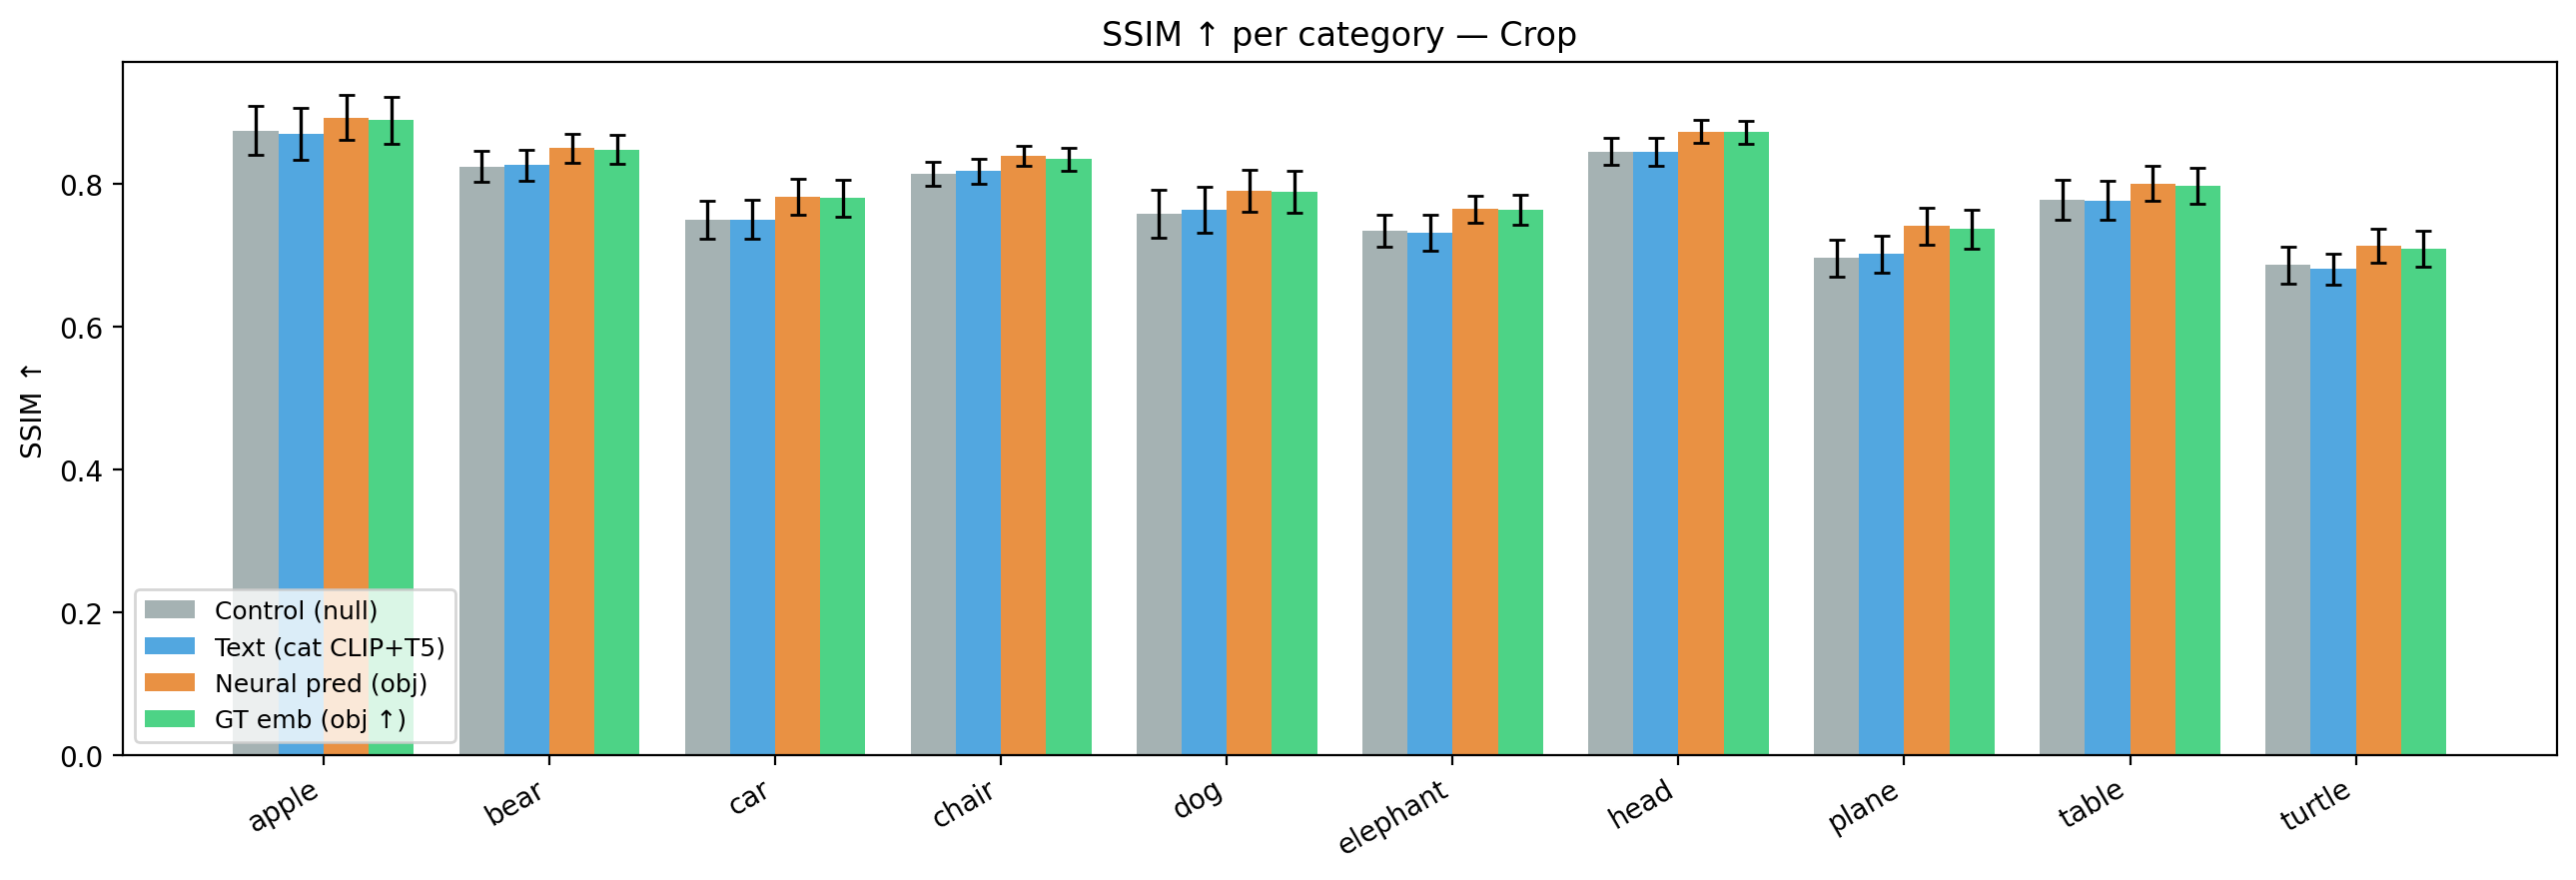

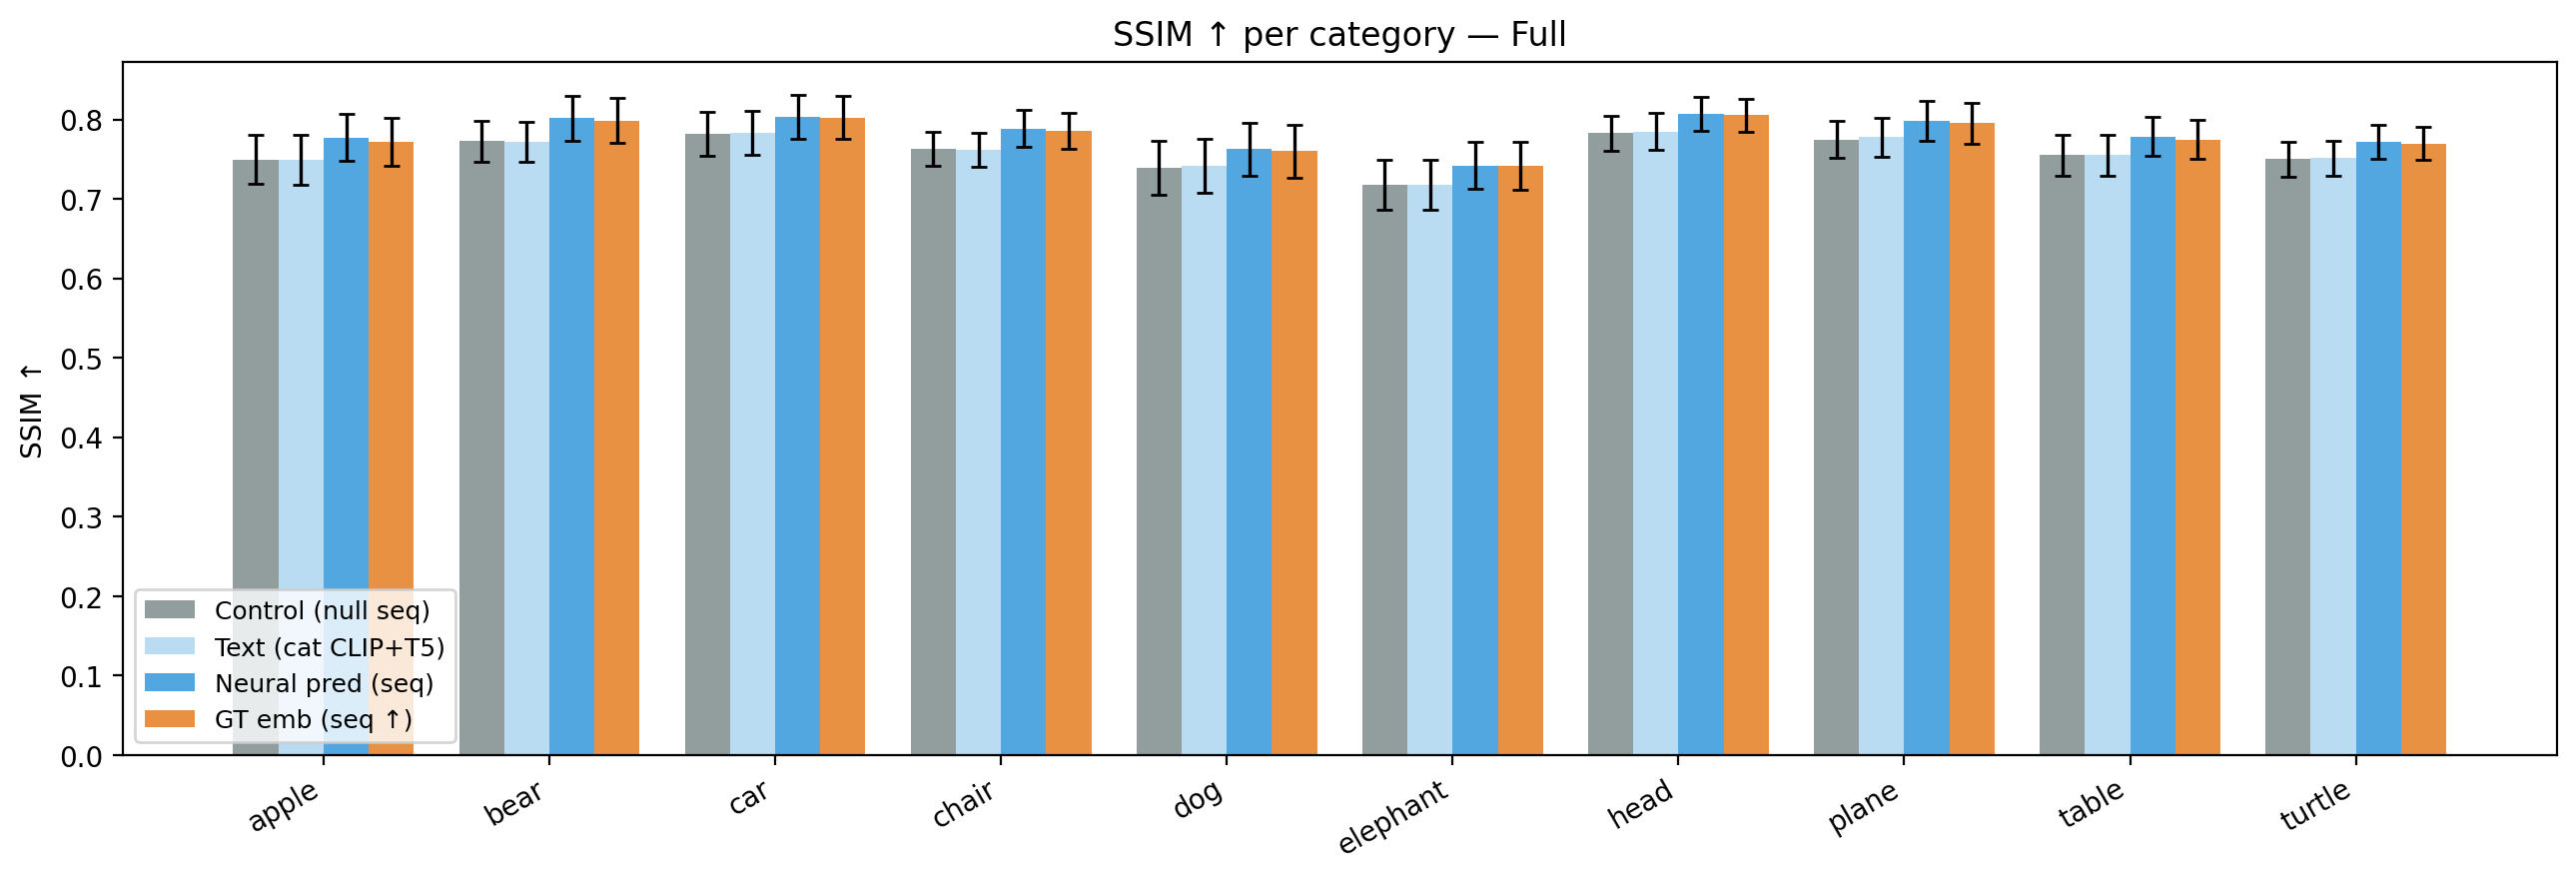

In [40]:
# Per-category bar charts — SSIM
cat_ids = np.array(test_idx) // HVM_N_VAR

def make_cat_bars(results, cond_keys, cond_names, colors, metric_key, metric_label, title_suffix):
    x = np.arange(len(HVM_CATEGORIES))
    w = 0.8 / len(cond_keys)
    offsets = np.linspace(-(len(cond_keys)-1)/2, (len(cond_keys)-1)/2, len(cond_keys)) * w
    fig, ax = plt.subplots(figsize=(13, 4.5))
    for offset, key, name, color in zip(offsets, cond_keys, cond_names, colors):
        label = name.replace('\n', ' ')
        vals = results[key][metric_key]
        cat_means = [vals[cat_ids == i].mean() for i in range(len(HVM_CATEGORIES))]
        cat_sems  = [vals[cat_ids == i].std() / np.sqrt((cat_ids == i).sum()) for i in range(len(HVM_CATEGORIES))]
        ax.bar(x + offset, cat_means, w, yerr=cat_sems, label=label, color=color,
               alpha=0.85, capsize=3, error_kw=dict(lw=1.2))
    ax.set_xticks(x)
    ax.set_xticklabels(HVM_CATEGORIES, rotation=30, ha='right')
    ax.set_ylabel(metric_label)
    ax.set_title(f'{metric_label} per category — {title_suffix}')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

make_cat_bars(crop_results, CROP_COND_KEYS, CROP_COND_NAMES, CROP_COLORS,
              'ssim', 'SSIM ↑', 'Crop')
make_cat_bars(full_results, FULL_COND_KEYS, FULL_COND_NAMES, FULL_COLORS,
              'ssim', 'SSIM ↑', 'Full')

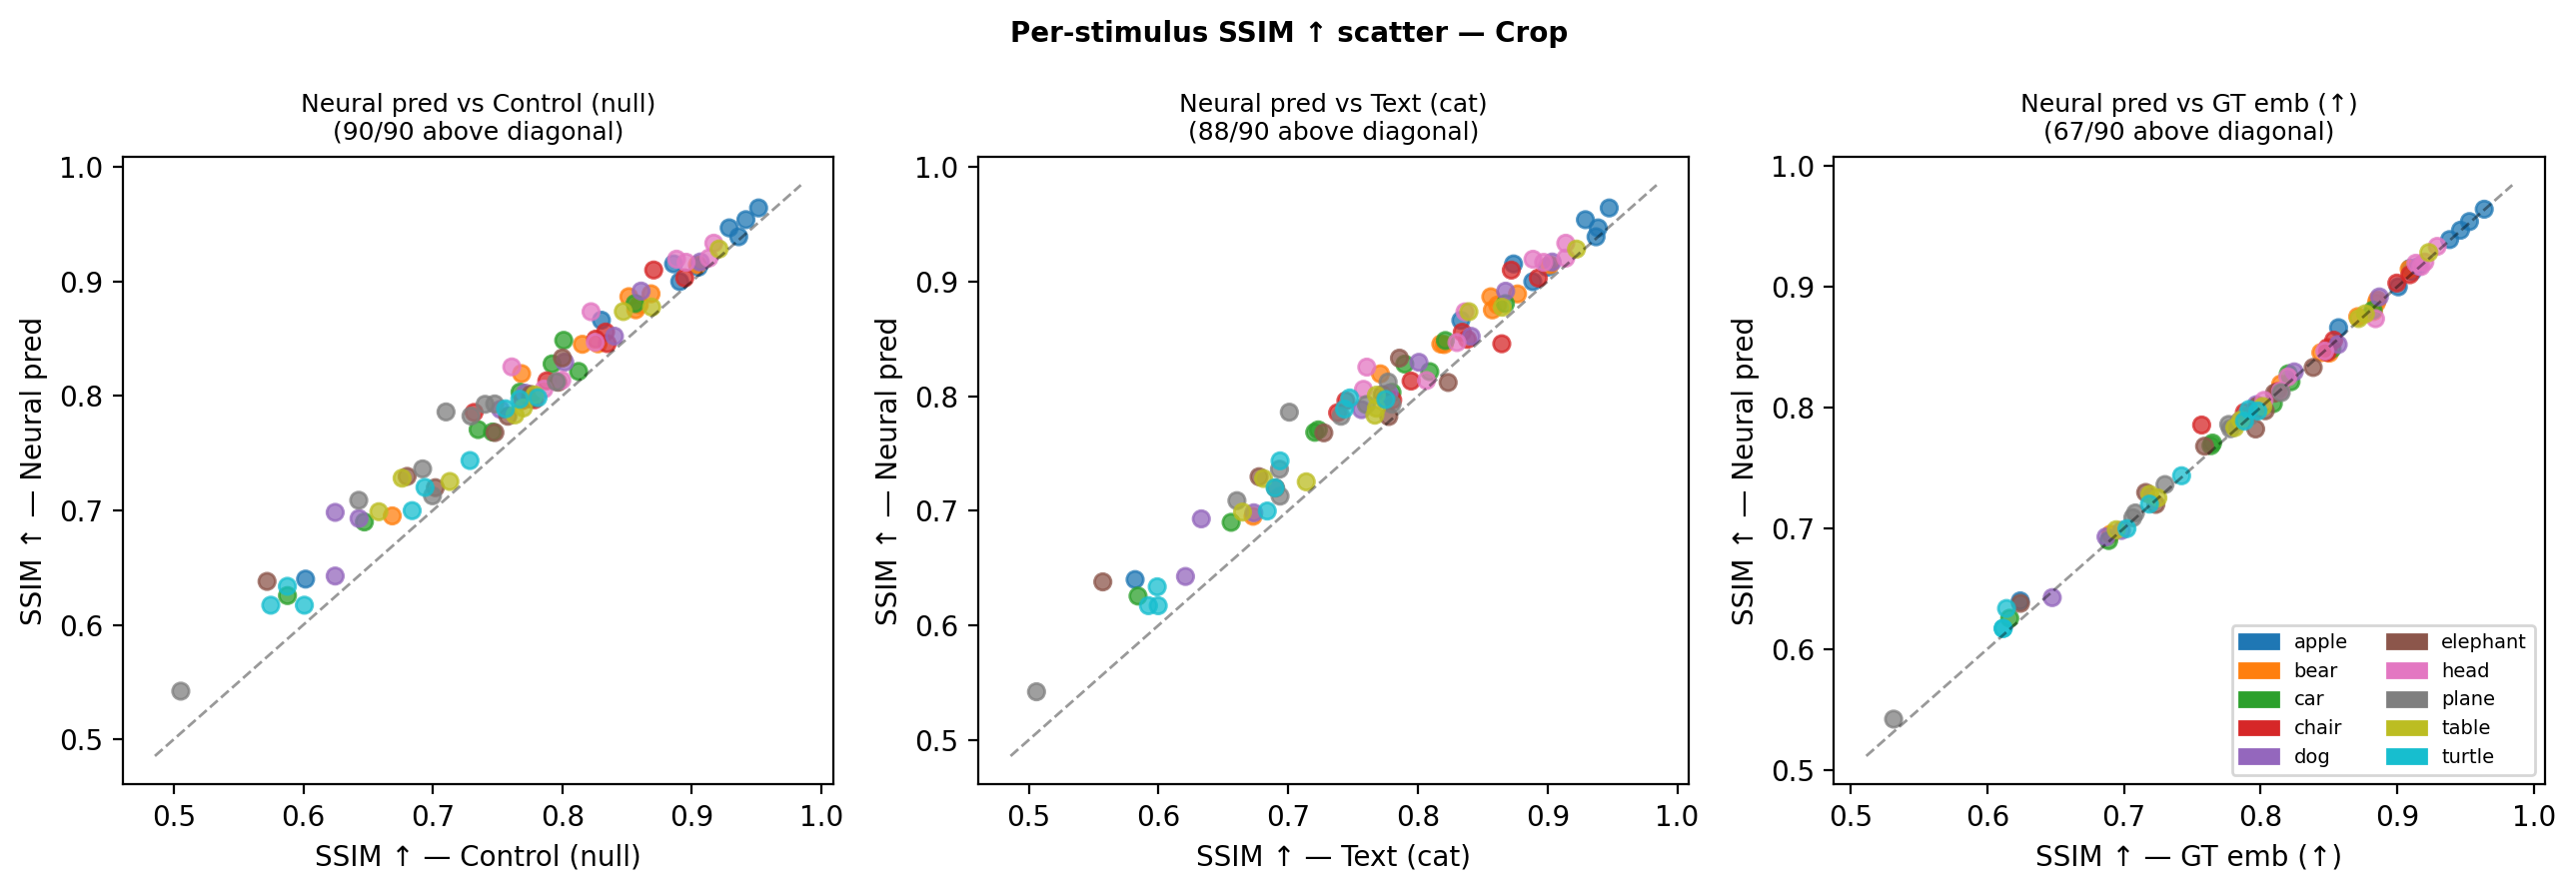

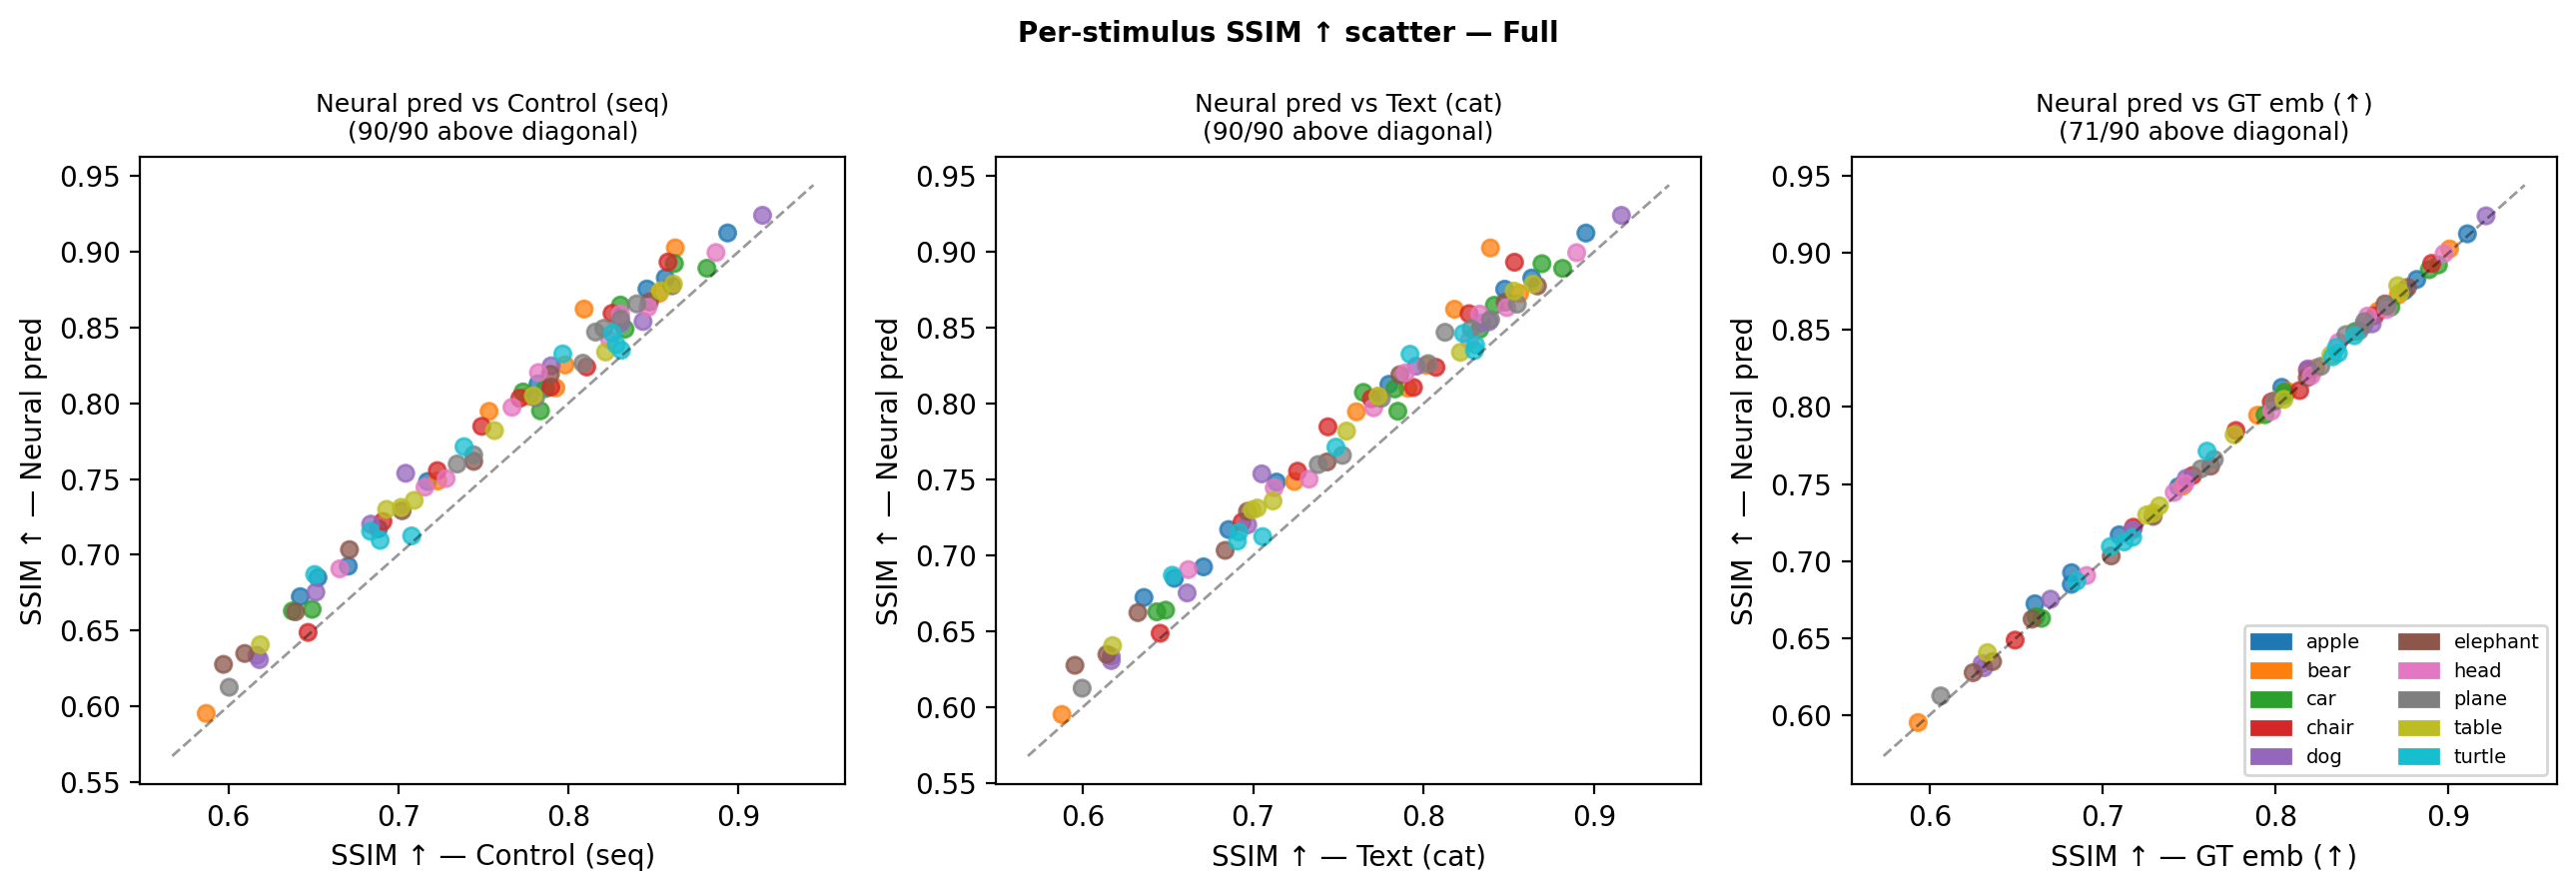

In [41]:
# Per-stimulus scatter — SSIM: Neural vs Control/Text/GT for crop and full
import matplotlib.patches as mpatches

cat_ids = np.array(test_idx) // HVM_N_VAR

CROP_SCATTER = [
    ('control',  'neural', 'Control (null)',    'Neural pred'),
    ('text',     'neural', 'Text (cat)',        'Neural pred'),
    ('gt',       'neural', 'GT emb (↑)',        'Neural pred'),
]
FULL_SCATTER = [
    ('ctrl_seq', 'neural', 'Control (seq)',     'Neural pred'),
    ('text',     'neural', 'Text (cat)',        'Neural pred'),
    ('gt',       'neural', 'GT emb (↑)',        'Neural pred'),
]

def make_scatter(results, scatter_pairs, metric_key, metric_label, title_suffix):
    fig, axes = plt.subplots(1, len(scatter_pairs), figsize=(13, 4.5))
    for ax, (x_key, y_key, x_label, y_label) in zip(axes, scatter_pairs):
        xv = results[x_key][metric_key]
        yv = results[y_key][metric_key]
        ax.scatter(xv, yv, c=cat_ids, cmap='tab10', s=35, alpha=0.75)
        lim = [min(xv.min(), yv.min()) - 0.02, max(xv.max(), yv.max()) + 0.02]
        ax.plot(lim, lim, 'k--', lw=1, alpha=0.4)
        n_above = (yv > xv).sum()
        ax.set_xlabel(f'{metric_label} — {x_label}')
        ax.set_ylabel(f'{metric_label} — {y_label}')
        ax.set_title(f'{y_label} vs {x_label}\n({n_above}/90 above diagonal)', fontsize=9)
    handles = [mpatches.Patch(color=plt.cm.tab10(i / 10), label=c)
               for i, c in enumerate(HVM_CATEGORIES)]
    axes[-1].legend(handles=handles, fontsize=7, ncol=2, loc='lower right')
    fig.suptitle(f'Per-stimulus {metric_label} scatter — {title_suffix}', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

make_scatter(crop_results, CROP_SCATTER, 'ssim', 'SSIM ↑', 'Crop')
make_scatter(full_results, FULL_SCATTER, 'ssim', 'SSIM ↑', 'Full')

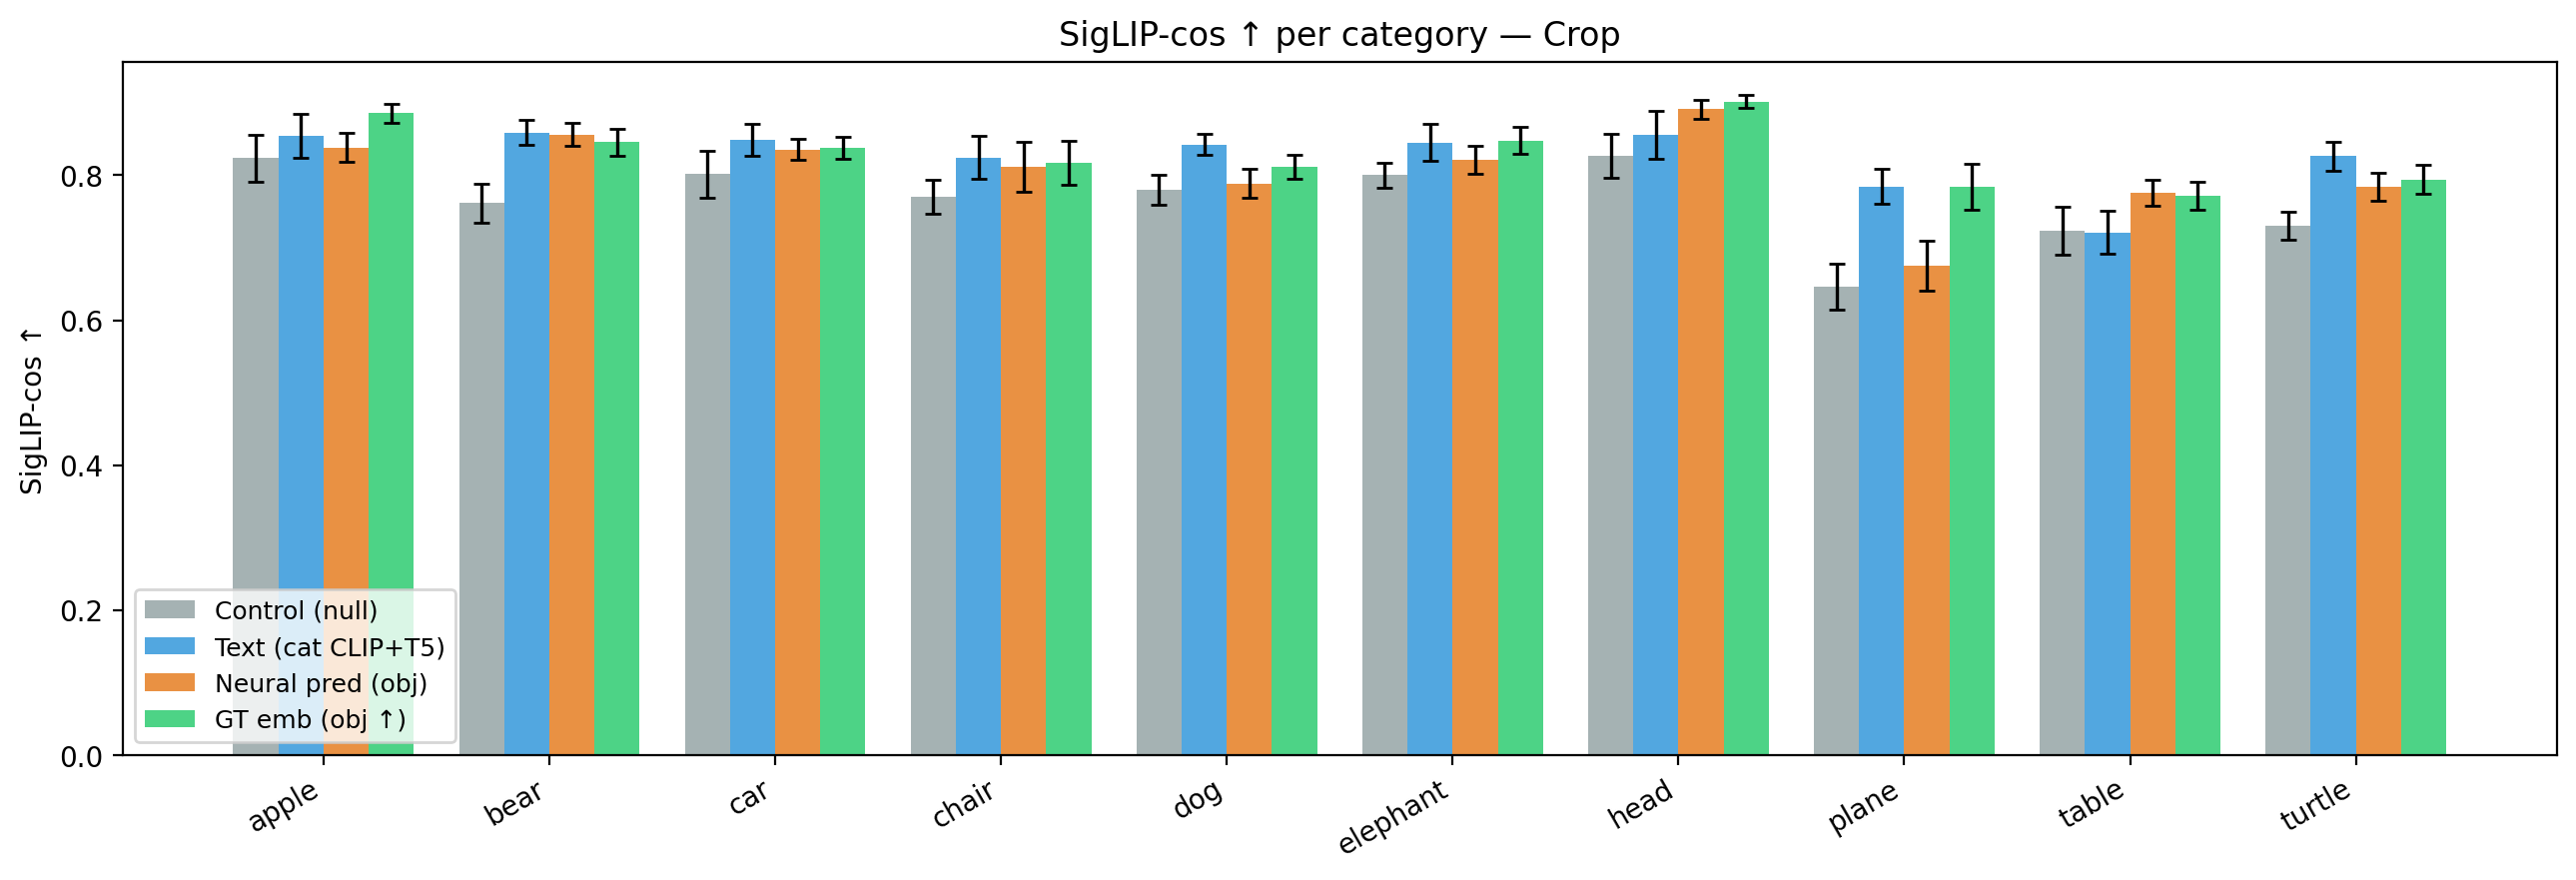

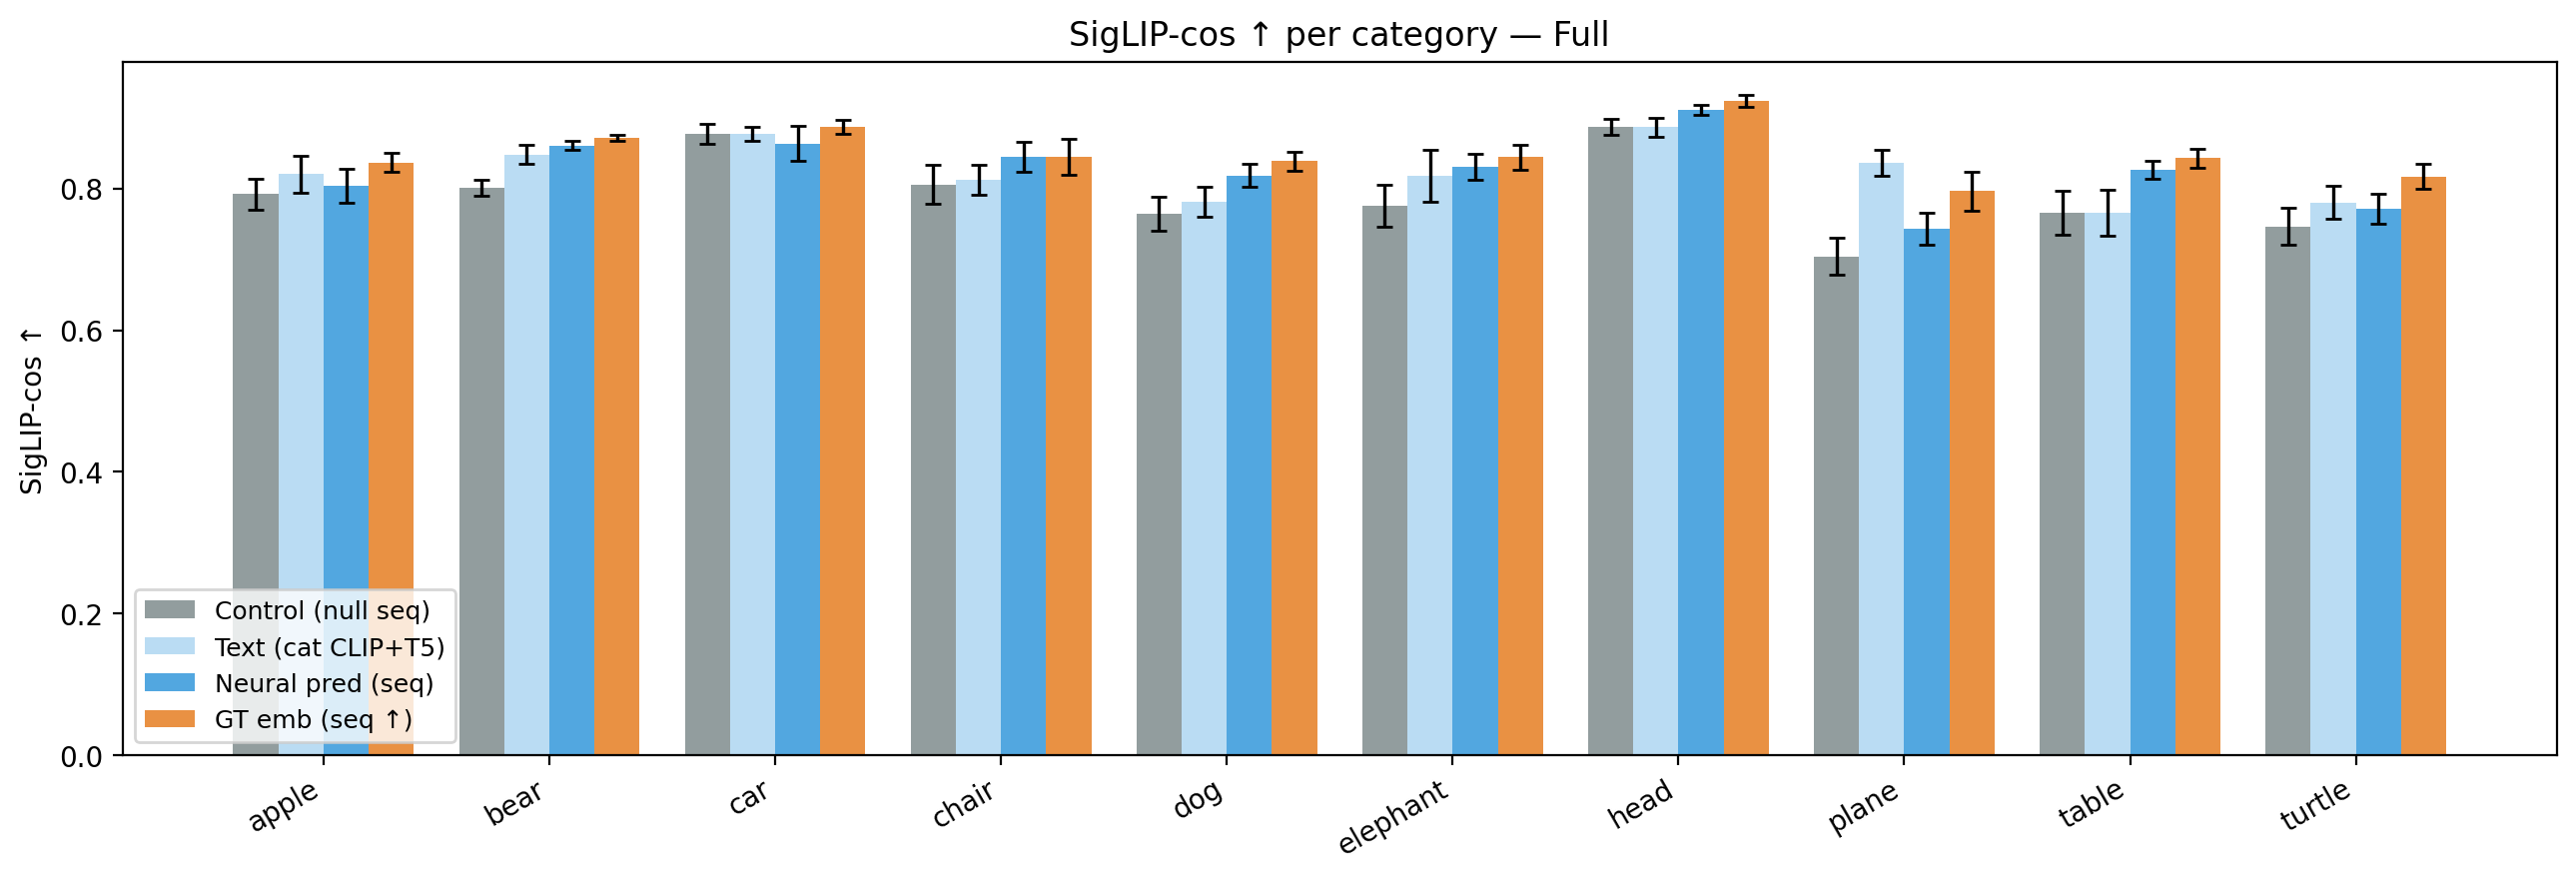

In [42]:
# Per-category bar charts — SigLIP-cos
make_cat_bars(crop_results, CROP_COND_KEYS, CROP_COND_NAMES, CROP_COLORS,
              'siglip_cos', 'SigLIP-cos ↑', 'Crop')
make_cat_bars(full_results, FULL_COND_KEYS, FULL_COND_NAMES, FULL_COLORS,
              'siglip_cos', 'SigLIP-cos ↑', 'Full')

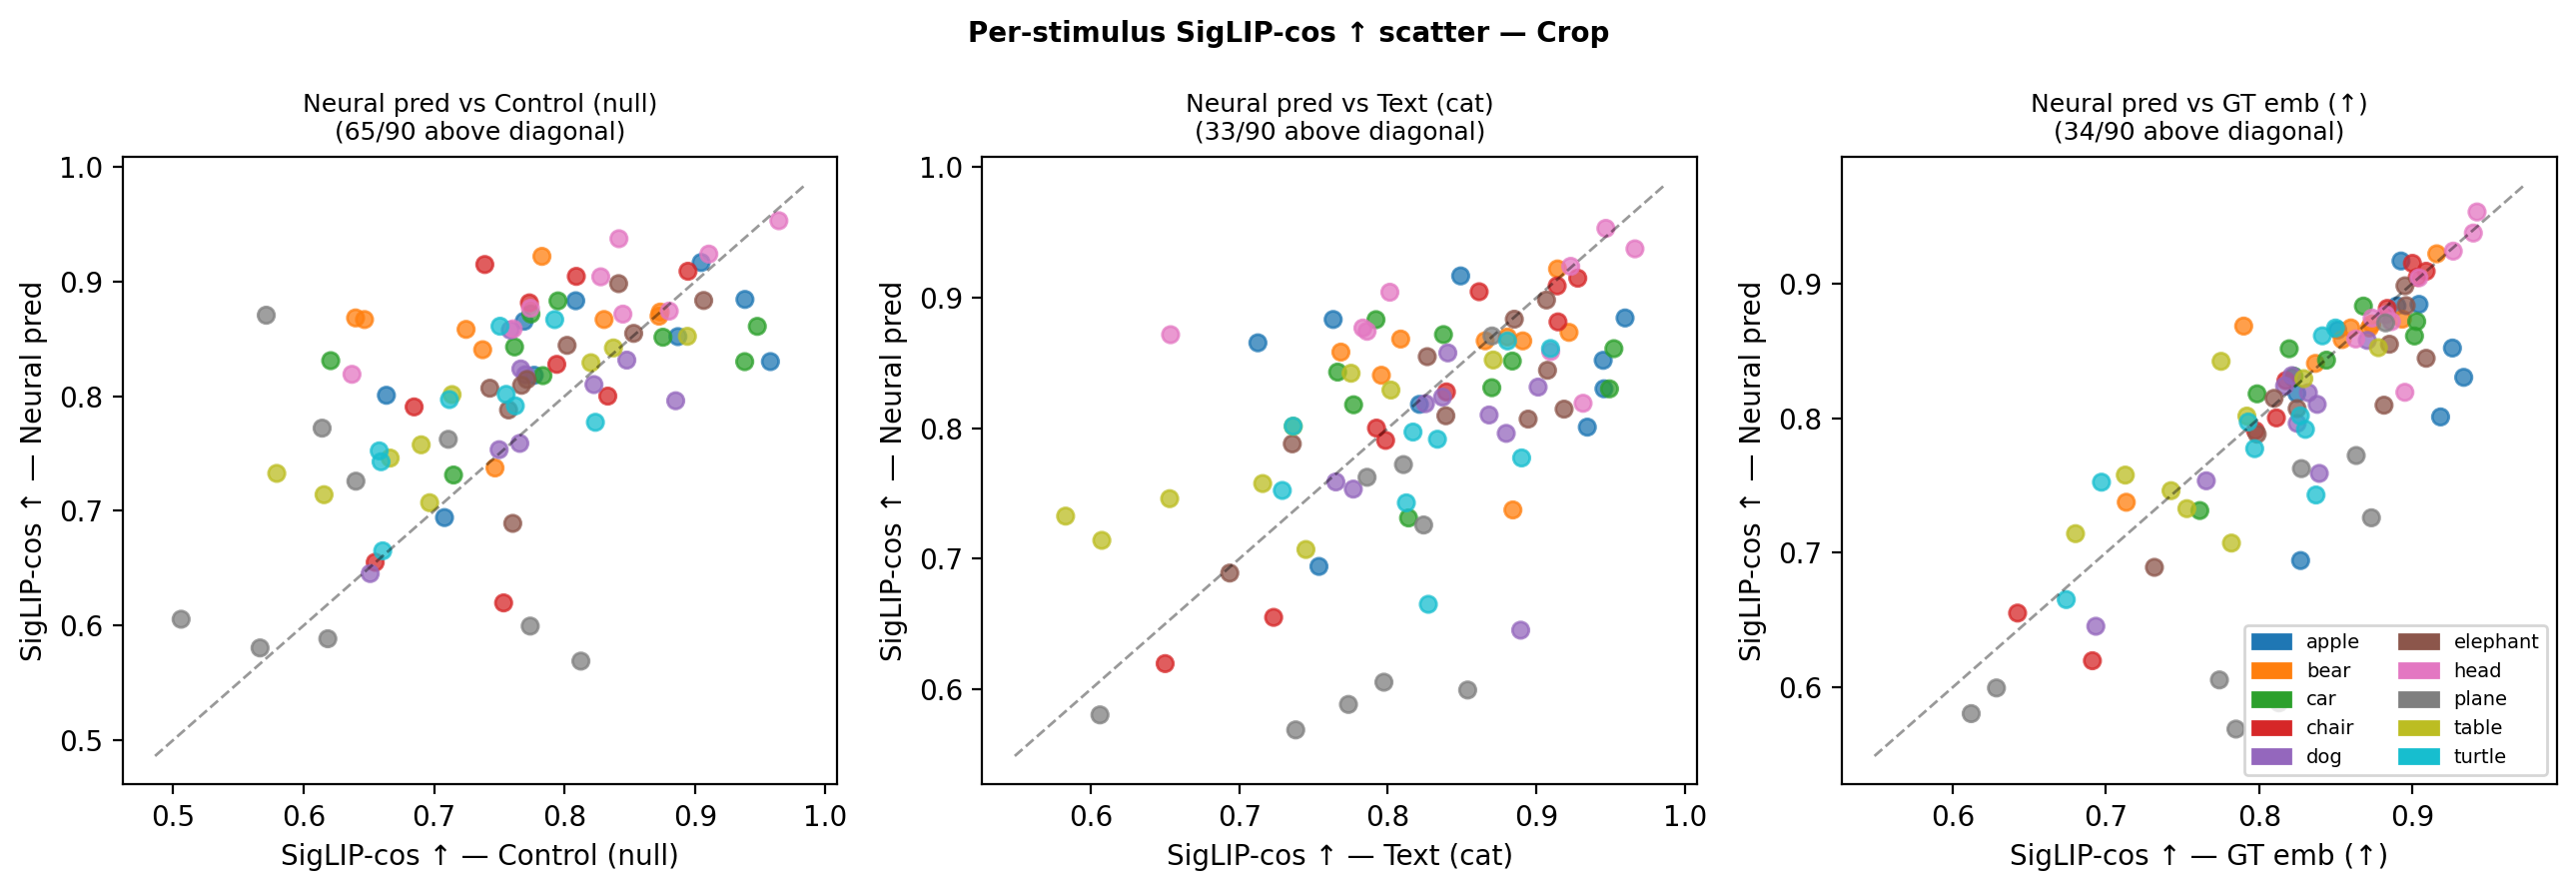

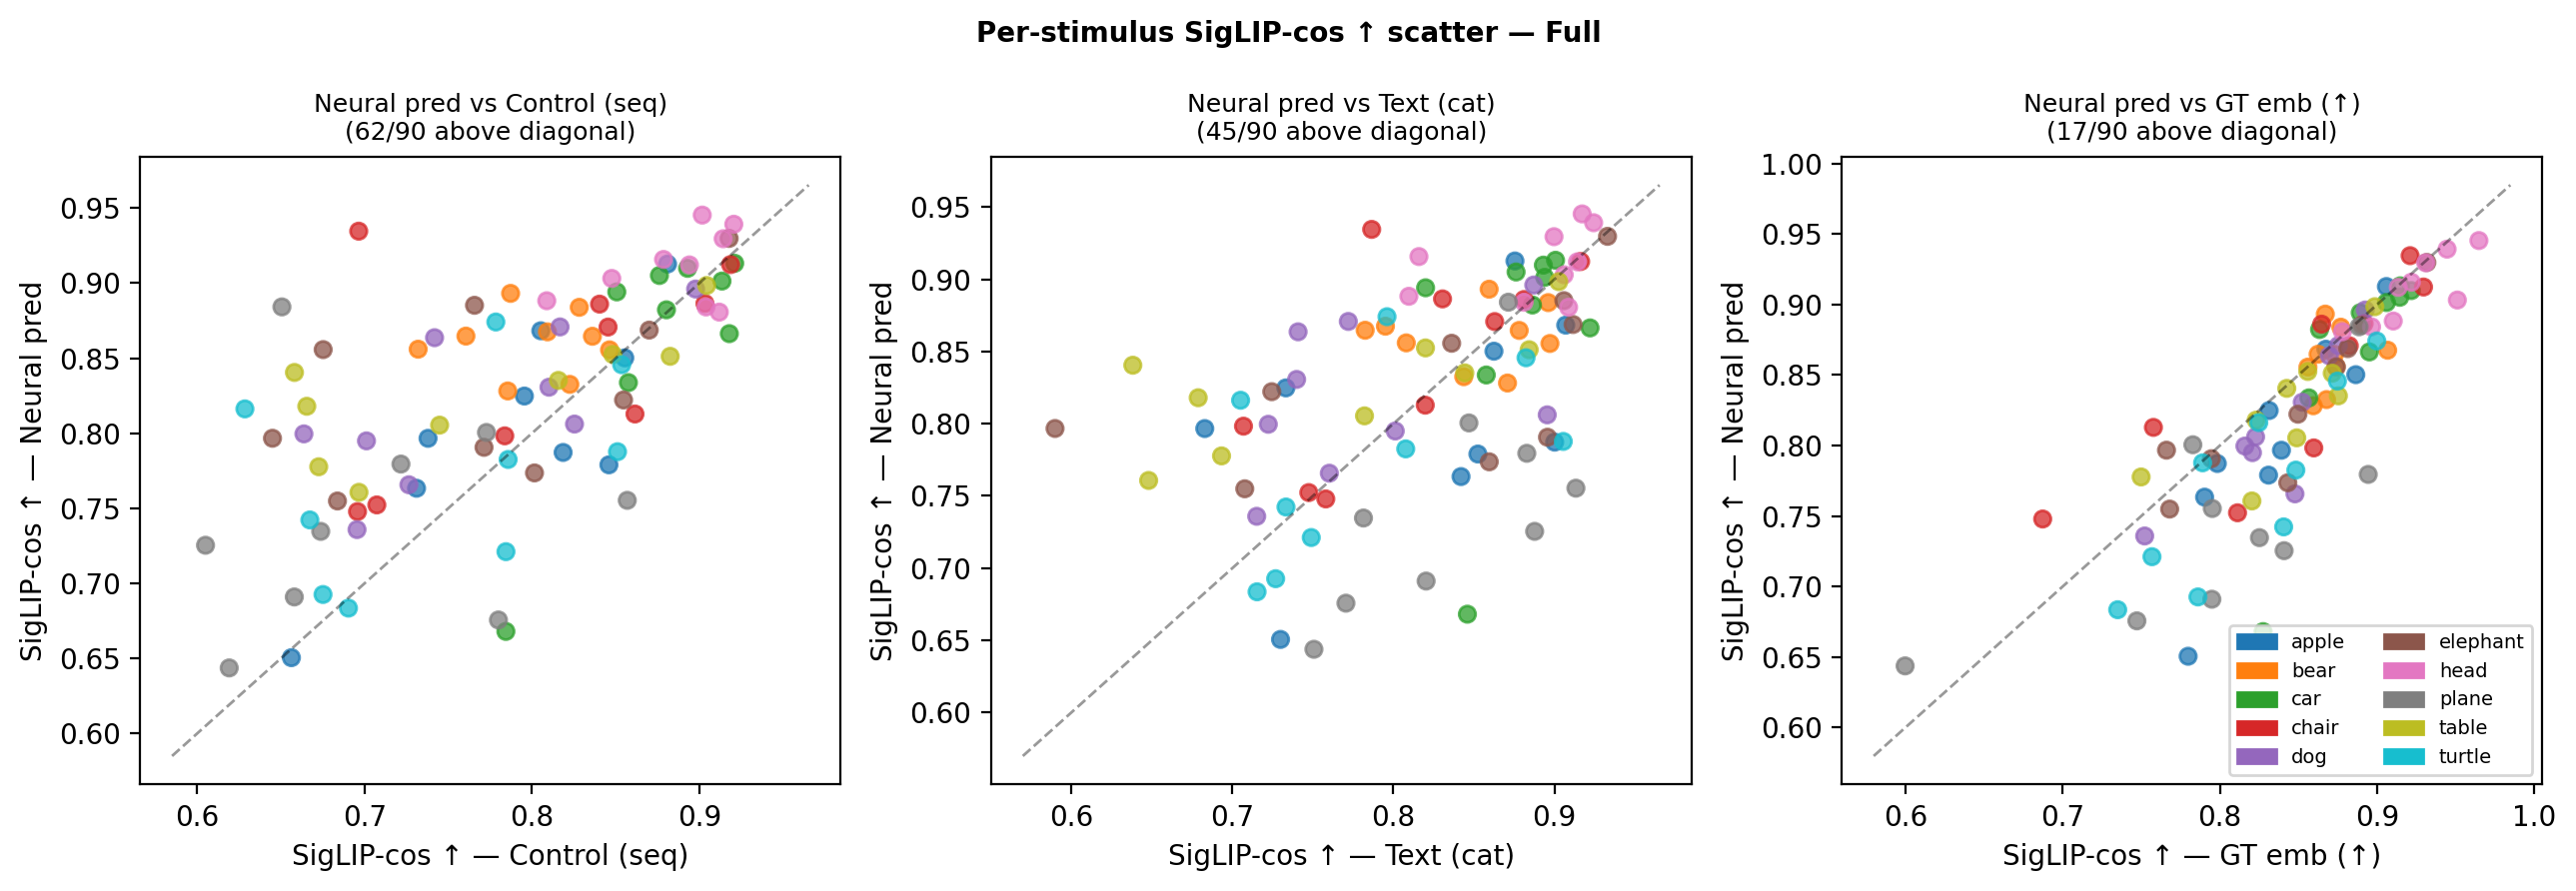

In [43]:
# Per-stimulus scatter — SigLIP-cos
make_scatter(crop_results, CROP_SCATTER, 'siglip_cos', 'SigLIP-cos ↑', 'Crop')
make_scatter(full_results, FULL_SCATTER, 'siglip_cos', 'SigLIP-cos ↑', 'Full')